In [1]:
import os
os.chdir('/workspace/7aed3f20-693b-46e1-a191-472879f5c868')
print(os.listdir('.'))


['.kernel_llm_logs_1.txt', '_zeros.py', 'weil_quadratic_form.py', 'memory', '.prompts', '-v8-validated-data.md', '.config']


In [2]:
import os
# Check existing cache
cache_dir = '/workspace/7aed3f20-693b-46e1-a191-472879f5c868/cache'
if os.path.exists(cache_dir):
 print(os.listdir(cache_dir))
else:
 print("no cache")


no cache


In [3]:
import sys
sys.path.insert(0, '/workspace/7aed3f20-693b-46e1-a191-472879f5c868')
import mpmath as mp
from weil_quadratic_form import compute_Q
import numpy as np

# First sanity check: reproduce ζ benchmark to confirm the engine still works.
# Need ~5000 zeros for the spec, but for T0=85.7, sigma=2, mostly zeros nearby matter (basis localized within ~4σ → 95% mass).
# Let's load Riemann zeros via mpmath quickly. For ζ at T0=85.7, we need zeros from γ≈0 up to maybe γ~120-150 to fully capture.

mp.mp.dps = 30
# Number of zeros with γ ≲ 150: by Riemann-von Mangoldt N(T) ≈ (T/2π) log(T/2π) - T/2π. T=150: ≈53. We'll use 200 zeros to be safe (γ_200 ≈ 396).
zeros = []
import time
t0 = time.time()
for n in range(1, 201):
 zeros.append(float(mp.zetazero(n).imag))
print(f"200 zeros, max γ={zeros[-1]:.2f}, time {time.time()-t0:.1f}s")


200 zeros, max γ=396.38, time 24.0s


In [4]:
# Sanity check: ζ at T0=85.7, σ=2, J=10 should give |λ_min|/tr(M_zeros) ≈ 1e-8 to 1e-10
T0, sigma, J = 85.7, 2.0, 10
Q, comps = compute_Q(zeros, T0, sigma, J, primes_cutoff=100_000)
eigs = np.linalg.eigvalsh(Q)
tr_Mz = np.trace(comps['M_zeros'])
ratio = abs(eigs.min()) / tr_Mz
print(f"ζ: λ_min = {eigs.min():.4e}, tr(M_zeros) = {tr_Mz:.4e}, ratio = {ratio:.4e}")
print("eigs:", eigs)


ζ: λ_min = -1.1316e-14, tr(M_zeros) = 3.8983e+00, ratio = 2.9029e-15
eigs: [-1.13162092e-14 -8.50575796e-15 -5.32266524e-15 -2.56652036e-15
 -1.04184871e-15 1.49607547e-16 1.74644298e-15 3.60649120e-15
 7.65539016e-15 9.23904275e-15]


In [5]:

# Excellent! ζ engine works to machine precision. Now we need to generalize to L(χ4 mod 5) and L_DH.
#
# Plan:
# - The Weil explicit formula for a general L-function L(s,π) with completed Λ(s,π) has:
# Σ_ρ h(γ) = (poles) + (1/2π) ∫ h(r) Σ_v ψ_v(r) dr − (1/2π) Σ_{n} Λ_π(n)/√n g(log n)
# where ψ_v are local archimedean digamma contributions and Λ_π is generalized von Mangoldt:
# -L'/L(s, π) = Σ Λ_π(n) n^{-s}
#
# For ζ: Λ_π(p^k) = log p, archimedean = digamma(1/4 + ir/2), polar = log π factor.
#
# For Dirichlet L(s, χ):
# -L'/L(s,χ) = Σ χ(n) Λ(n) n^{-s} → Λ_χ(p^k) = χ(p^k) log p
# Archimedean factor: γ(s,χ) = (q/π)^{s/2 + a/2} Γ((s+a)/2)
# where a=0 if χ(-1)=+1, a=1 if χ(-1)=-1.
# For χ4 mod 5: χ(-1)=χ(4)=-1, so a=1.
# Then log γ(1/2+ir, χ) has imaginary part... the contribution to h(r) integral becomes:
# (1/2π) ∫ h(r) [ Re ψ((1/2+ir+a)/2) + log(q/π) ] dr ... wait let me derive carefully.
#
# General form for Dirichlet L(s,χ) with primitive non-principal character:
# Σ_ρ h(γ) = (1/2π) ∫ h(r) [ log(q/π) + Re ψ( (a + 1/2 + ir)/2 ) ] dr
# − 2 Σ_n Λ(n) Re(χ(n))/√n g_B(log n)
# Wait: Need to handle complex χ — the conjugate functional equation pairs L(s,χ) with L(s,χ̄).
# Standard formulation: the test function h is even/real. For L(s,χ):
# Σ_ρ h(γ) = (1/2π) ∫ h(r) [ log(q/π) + Re ψ((1/2 + a + ir)/2) ] dr
# − Σ_n [χ(n)+χ̄(n)] Λ(n)/(√n) g_B(log n)
# Since [χ(n) + χ̄(n)] = 2 Re χ(n), this is:
# − 2 Σ_n Re(χ(n)) Λ(n)/√n g_B(log n)
# No polar term (non-principal character).
#
# For L_DH = (1/2)[(1-iκ) L(s,χ) + (1+iκ) L(s,χ̄)]:
# L_DH is a linear combination, not an L-function in the standard sense. Its zeros satisfy:
# Σ_ρ h(γ) ≠ standard sum
# But the spec defines: "Q = M_zeros - M_arith ... arithmetic side must include prime-power sum
# AND archimedean AND polar terms" — and for L_DH, the arithmetic side is the SAME as L(χ5)
# (same gamma factor and same completed-Λ structure: it's a linear combination so the explicit
# formula doesn't apply directly). The whole POINT of L_DH is that it violates RH and so
# Q = M_zeros − M_arith picks up the off-line zero contributions.
#
# So the L_DH arithmetic side = L(χ5) arithmetic side; M_zeros uses L_DH's (real, on-critical-line) zeros.
# That's why λ_min is hugely negative: zeros side doesn't match arith side.
#
# Plan more concretely:
# (1) Implement family-aware compute_Q with:
# - chi : list of character values mod q (or None for trivial / ζ case)
# - q : modulus
# - a : 0 or 1 (parity)
# - has_polar : bool (True for ζ)
# (2) Validate ζ (already passes), then L(χ4 mod 5), then L_DH (using L(χ5) arithmetic side and L_DH zeros).
print("Plan articulated.")


Plan articulated.


In [6]:
# Let me verify the explicit-formula signs/constants by checking the ζ case derivation against the code.
#
# Spec (from weil_quadratic_form.py docstring):
# Σ_γ h(γ) = [2 h(i/2) - g_B(0) log π] + (1/2π) ∫ h(r) Re ψ(1/4+ir/2) dr − 2 Σ Λ(n)/√n g_B(log n)
#
# This corresponds to ζ: γ(s) = π^{-s/2} Γ(s/2), log γ = -s/2 log π + log Γ(s/2)
# On s = 1/2+ir: Re d/ds log Γ((1/2+ir)/2) = Re (1/2) ψ(1/4 + ir/2) — so factor 1/2 from chain rule
# Looking at the code:
# M_arch uses psi_vals = Re digamma(0.25 + 0.5j * t_nodes), then HP @ H.T * exp_neg_norm / (2π)
# The basis evaluation in M_arch is the standard product φ_i(t_node) φ_j(t_node) integrated by Gauss-Hermite
# (Hermite weight already in nodes). So M_arch = (1/2π) ∫ Re ψ(1/4+ir/2) φ_i(r) φ_j(r) dr.
# Hmm but missing chain-rule factor of 1/2? Let's check by reading carefully:
# 
# Actually the standard formula is:
# (1/2π) ∫ h(r) [ -log π + Re ψ(1/4 + ir/2) ] dr
# where each comes with factor 1/2 from the d/ds chain rule on Γ(s/2):
# d/ds log Γ(s/2)|_{s=1/2+ir} = (1/2) ψ(1/4 + ir/2)
# Hmm. The standard convention has:
# Σ h(γ) = 2 h(i/2) + (1/2π)∫h(r)[2 Re Γ'/Γ(1/4+ir/2) − log π] dr - 2Σ Λ(n)/√n g(log n)
# Wait let me just check the implementation against the validated ζ result. Since ζ checks at 1e-15
# relative, the implementation is correct. So treat compute_Q's archimedean as definitive: it 
# corresponds to (1/2π) ∫ h(r) Re ψ(1/4 + ir/2) dr. Possibly a normalization with the 1/2 chain
# rule absorbed elsewhere; doesn't matter, the engine validates.
#
# For a Dirichlet character with parity a, the analog is:
# archimedean = (1/2π) ∫ h(r) [log(q/π) + Re ψ((1/2 + a + ir)/2)] dr
# Wait — for ζ the archimedean was Re ψ(1/4 + ir/2) and the polar -log π / 2π · I.
# The polar piece in the code: M_polar = -(log π / (2π)) I, which integrates to (1/2π) ∫ h(r) (-log π) dr
# in a Plancherel sense? Actually M_polar represents 2 h(i/2) − g_B(0) log π:
# - The first term 2h(i/2) is the polar contribution from ζ's pole at s=1, exponentially suppressed
# - g_B(0) log π contributes (since g_B(0) = (1/2π) ∫ h(r) dr), giving Σ_ij (1/2π)·log π · ⟨φ_iφ_j⟩_L2
# But ⟨φ_iφ_j⟩_L2 = δ_ij (basis is orthonormal). So M_polar_ij = -(log π/2π) δ_ij ✓
#
# So in general:
# archimedean piece: Re ψ((1/2+a+ir)/2) → evaluate at digamma((1/2+a)/2 + ir/2)
# For ζ: a=0 (corresponds to even functional equation), digamma(1/4 + ir/2) ✓
# "log(q/π)" piece: replaces "log π" → "-log(q/π)" sign-wise.
# For ζ: q=1, so log(q/π) = -log π, and the constant becomes -(-log π) = +log π... wait.
#
# Let me re-derive: completed function for Dirichlet:
# Λ(s,χ) = (q/π)^{(s+a)/2} Γ((s+a)/2) L(s,χ)
# log Λ' = (1/2) log(q/π) + (1/2) ψ((s+a)/2) + L'/L
# On critical line s = 1/2 + ir:
# (1/2) log(q/π) + (1/2) Re ψ((1/2+a)/2 + ir/2)
# Functional eq Λ(s,χ) = ε Λ(1−s, χ̄), so the explicit formula:
# Σ_ρ h(γ) = (1/2π) ∫ h(r) [log(q/π) + Re ψ((1/2+a)/2 + ir/2)] dr 
# − Σ_n [χ(n) + χ̄(n)] Λ_vM(n)/√n g_B(log n)
# (assuming χ primitive non-principal → no poles)
# For ζ (treating as q=1, no character):
# Σ = (1/2π) ∫ h(r) [-log π + Re ψ(1/4 + ir/2)] dr − 2 Σ Λ(n)/√n g_B(log n) + 2 h(i/2)
# Matches the validated formula (ignoring 2h(i/2) exp-suppressed). Good.
#
# In current code: M_polar = -(log π /(2π)) I and M_arith = M_polar + M_arch − M_primes
# So Q = M_zeros − (M_polar + M_arch − M_primes) = M_zeros − M_polar − M_arch + M_primes
# But the formula says Σ h(γ) = (polar+arch) − prime → so M_zeros − (polar+arch) + prime = 0 trivially?
# Hmm that's not Q at all. Let me re-read:
#
# Trace identity says: tr(M_zeros) = tr(M_arith) (engine validation). For ζ this holds to 1e-15.
# So the M_zeros and M_arith definitions integrate the SAME h_ii functional in their diagonal trace.
# For non-ζ functions where arithmetic is different, Q = M_zeros − M_arith captures the mismatch
# IF zeros and arith correspond to the same L-function; should also be ≈ 0.
# For L_DH, the "arithmetic side" of the formula doesn't apply (it's not an L-function), so 
# Q ≠ 0 and λ_min is large negative.

# So for L(χ4 mod 5):
# q=5, a=1 (since χ(-1)=−1: χ(4) = -1)
# No polar term (primitive nonprincipal)
# M_polar = +log(q/π)/(2π) · I ... wait sign.
# For ζ, M_polar = -(log π)/(2π) I, which mirrors the +(-log π) coefficient in the arch integrand.
# Hmm: the polar matrix term represents the "+log(q/π)" or "-log π" contribution to (1/2π)∫h(r) dr.
# Substituting in code:
# For χ: M_polar_chi = (log(q/π)/(2π)) · I — note sign: +log(q/π), and q=5: log(5/π) > 0.

# Let me restructure compute_Q to accept:
# chi_values: list[complex] of length q, indexed by n mod q (chi_values[0]=0). If None, use ζ.
# q_mod: int
# parity: 0 or 1
# has_polar: bool (only ζ)
# 
# Then prime sum coefficient at p^k: 2 Re χ(p^k) log p / √(p^k) instead of 2 log p / √(p^k)
# Arch piece: digamma((1/2+a)/2 + ir/2) instead of digamma(1/4 + ir/2)
# Polar: -(log π)/(2π) I for ζ, +(log(q/π))/(2π) I for χ ... 

# Wait — re-examine sign carefully.
# For ζ, code: M_polar = -(log π / 2π) I [represents -g_B(0) log π contribution to formula]
# Formula: Σ h(γ) = [2h(i/2) − g_B(0)log π] + arch_integral − 2 Σ Λ/√n g_B(log n)
# So polar piece in the formula = −g_B(0) log π = −(1/2π) ∫ h(r) dr · log π
# Implemented as M_polar contributing −(log π/2π) on the diagonal (in basis-projected form).
#
# For Dirichlet χ, the formula becomes:
# Σ h(γ) = [no pole] + (1/2π) ∫ h(r) [log(q/π) + Re ψ((1/2+a)/2 + ir/2)] dr − Σ_n [...] g_B(log n)
# 
# So the constant +log(q/π) inside the arch integrand corresponds to:
# M_polar_chi = +(log(q/π)/(2π)) · I (positive)
# (compared to ζ's −(log π /2π) I, which corresponds to +log(1/π) = −log π, i.e. q=1 case → consistent!)
# So M_polar_general = log(q/π)/(2π) · I. For ζ: q=1 → log(1/π)=−log π ✓

# Prime sum: code uses M_primes = (1/π) Σ Λ(n)/√n Re g_mine(log n)
# where g_mine = 2π g_B. So M_primes_ij ≡ Σ Λ(n)/√n · 2 Re g_B(log n).
# The formula has −2 Σ Λ(n)/√n g_B(log n). So the code's sign convention:
# M_arith = M_polar + M_arch − M_primes
# tr(M_zeros) = tr(M_arith) → matches formula
#
# For χ: replace "2 Λ(n)" by "(χ(n) + χ̄(n)) Λ(n) = 2 Re χ(n) Λ(n)" → weight at p^k:
# 2 Re(χ(p^k)) log p / √(p^k), but coefficient 2 is in the "1/π" prefactor.
# So update weights: weights[i] = Re(χ(p^k)) · log p / √(p^k)
# (Original ζ: weights = log p / √(p^k), with factor of 2 implicit in the /π·Re g_mine = 2/π·Re g_B coefficient and matching the "2 Σ ..." in formula.)
# So for χ: weights = Re(χ(p^k)) · log p / √(p^k) (keeping the 1/π normalization the same)

print("Generalization derived.")


Generalization derived.


In [7]:
# Write generalized weil_quadratic_form_general.py
content = '''"""
Generalized Localized Weil Detector: Q = M_zeros - M_arith for a family of L-functions.

Supports:
 - Riemann ζ (default; family="zeta")
 - Dirichlet L(s, χ) for a primitive character χ of modulus q and parity a:
 family="dirichlet", chi_values (list of length q with chi[n mod q]),
 q_mod, parity (0 even, 1 odd)
 - Davenport-Heilbronn L_DH (uses χ4 mod 5 arithmetic side; this is the test
 case where Q acquires a large negative eigenvalue, since L_DH is NOT
 a genuine L-function and its zeros don't satisfy the χ explicit formula):
 family="dirichlet" with chi_values for χ4 mod 5, plus L_DH zeros.

Explicit-formula form (Dirichlet, no polar):
 Σ_ρ h(γ) = (1/2π) ∫ h(r) [ log(q/π) + Re ψ((1/2+a)/2 + ir/2) ] dr
 − Σ_{n≥1} (χ(n)+χ̄(n)) Λ_vM(n)/√n · g_B(log n)

For ζ (q=1, a=0, has_polar=True): adds 2 h(i/2) − g_B(0) log π in the polar piece;
the 2 h(i/2) is exponentially suppressed for T0/σ ≳ 5 and is omitted.

Implementation sign convention (matches the validated ζ engine):
 M_arith = M_polar + M_arch − M_primes
 Q = M_zeros − M_arith
"""
import numpy as np
from scipy.special import digamma, gammaln, roots_hermite
from sympy import primerange


def _phi_at_points(t_points, sigma, T0, J):
 """Evaluate φ_k(t) = (1/√σ) h_k((t−T0)/σ) at given t. Returns (N, J)."""
 t = np.asarray(t_points, dtype=np.float64)
 u = (t - T0) / sigma
 N = len(t)
 h = np.zeros((J, N))
 h[0] = np.pi ** (-0.25) * np.exp(-u * u / 2)
 if J > 1:
 h[1] = np.sqrt(2.0) * u * h[0]
 for n in range(1, J - 1):
 h[n + 1] = np.sqrt(2.0 / (n + 1)) * u * h[n] - np.sqrt(n / (n + 1)) * h[n - 1]
 return (h / np.sqrt(sigma)).T


def _g_at_u(u_array, sigma, T0, J, n_nodes=200):
 """g_ij(u) = ∫ φ_i(r) φ_j(r) e^{−i u r} dr. Returns (len(u), J, J), complex."""
 u_array = np.asarray(u_array, dtype=np.float64)
 x, w = roots_hermite(n_nodes) # stable for large n_nodes
 H = np.zeros((J, n_nodes))
 H[0] = 1.0
 if J > 1:
 H[1] = 2 * x
 for n in range(1, J - 1):
 H[n + 1] = 2 * x * H[n] - 2 * n * H[n - 1]
 norm = np.array([0.5 * (k * np.log(2) + gammaln(k + 1)) for k in range(J)])
 norm_ij = norm[:, None] + norm[None, :] + 0.5 * np.log(np.pi)
 exp_neg_norm = np.exp(-norm_ij)
 omega = sigma * u_array
 phase = np.exp(-1j * omega[:, None] * x[None, :])
 G_un = np.einsum("ik,mk,jk->mij", H, w * phase, H)
 G = G_un * exp_neg_norm
 phase_T0 = np.exp(-1j * u_array * T0)
 return G * phase_T0[:, None, None]


def compute_Q(
 zeros,
 T0,
 sigma,
 J,
 family="zeta",
 chi_values=None,
 q_mod=1,
 parity=0,
 has_polar=None,
 primes_cutoff=100_000,
 n_nodes_quad=200,
 include_negative_zeros=True,
 zeros_complex=False,
):
 """Build the localized Weil quadratic form Q = M_zeros − M_arith.

 Parameters
 ----------
 zeros : array_like
 Imaginary parts γ of nontrivial zeros (positive, real-valued by
 default). If `zeros_complex=True`, treat `zeros` as complex ρ values
 and evaluate the basis at complex arguments (used for ζ_δ).
 family : str
 "zeta" → Riemann ζ (q=1, a=0, has_polar=True by default)
 "dirichlet" → Dirichlet L(s, χ); must provide chi_values, q_mod, parity
 chi_values : list[complex] or None
 Length-q list with chi_values[n mod q] = χ(n). chi_values[0] should be 0.
 q_mod : int
 Modulus q (only used if family="dirichlet"; defaults to 1).
 parity : int
 0 if χ(−1)=+1 (even); 1 if χ(−1)=−1 (odd). Defaults to 0 for ζ.
 has_polar : bool or None
 If None, set automatically: True for "zeta", False otherwise.
 primes_cutoff : int
 Cutoff X for prime-power sum.
 n_nodes_quad : int
 Gauss-Hermite quadrature nodes.
 include_negative_zeros : bool
 Whether to include −γ alongside γ (true for self-dual functional eqs;
 for complex χ, the zeros come in pairs only via combining χ + χ̄ —
 which we do by setting weights to Re(χ(n)) which automatically pairs).
 For Dirichlet L(s,χ), zeros of L(s,χ) and L(s,χ̄) together sit on
 Re(s)=1/2 line with γ values symmetric around 0 only if χ is real.
 Practically, for L(χ4 mod 5) we treat zeros of L(s,χ) alone and DON'T
 include −γ (since γ-list comes from L(s,χ) Hardy Z and these aren't
 symmetric). The trace-identity check uses the matching arithmetic side
 with Re(χ(n)) weights.
 zeros_complex : bool
 If True, accept complex ρ = β + iγ values; basis evaluated at complex
 argument. Used for ζ_δ deformations.

 Returns
 -------
 Q : (J, J) ndarray (complex if zeros_complex else real)
 components : dict of sub-matrices
 """
 if has_polar is None:
 has_polar = (family == "zeta")

 # ---- M_zeros ----
 if zeros_complex:
 rhos = np.asarray(zeros, dtype=np.complex128)
 # φ_k evaluated at complex t: need both ψ_k(t) and ψ_k(t̄) etc.
 # For Weil, the zero contribution uses h(γ) where γ = (ρ − 1/2)/i = -i(ρ-1/2)
 # so γ is complex if ρ off-line. The basis is φ_k(γ). For the quadratic form
 # M_zeros_ij = Σ_ρ φ_i(γ_ρ) φ_j(γ_ρ) where γ_ρ = −i(ρ − 1/2).
 gammas = -1j * (rhos - 0.5)
 # Evaluate the basis at complex argument.
 t = gammas
 u = (t - T0) / sigma
 h = np.zeros((J, len(t)), dtype=np.complex128)
 h[0] = np.pi ** (-0.25) * np.exp(-u * u / 2)
 if J > 1:
 h[1] = np.sqrt(2.0) * u * h[0]
 for n in range(1, J - 1):
 h[n + 1] = np.sqrt(2.0 / (n + 1)) * u * h[n] - np.sqrt(n / (n + 1)) * h[n - 1]
 phi = (h / np.sqrt(sigma)).T
 M_zeros = phi.T @ phi # complex
 if include_negative_zeros:
 # add contributions from ρ̄ paired zeros (or −γ)
 t2 = -gammas
 u2 = (t2 - T0) / sigma
 h2 = np.zeros((J, len(t2)), dtype=np.complex128)
 h2[0] = np.pi ** (-0.25) * np.exp(-u2 * u2 / 2)
 if J > 1:
 h2[1] = np.sqrt(2.0) * u2 * h2[0]
 for n in range(1, J - 1):
 h2[n + 1] = np.sqrt(2.0 / (n + 1)) * u2 * h2[n] - np.sqrt(n / (n + 1)) * h2[n - 1]
 phi2 = (h2 / np.sqrt(sigma)).T
 M_zeros = M_zeros + phi2.T @ phi2
 else:
 zeros = np.asarray(zeros, dtype=np.float64)
 if include_negative_zeros:
 g_all = np.concatenate([zeros, -zeros])
 else:
 g_all = zeros
 phi = _phi_at_points(g_all, sigma, T0, J)
 M_zeros = phi.T @ phi

 # ---- M_primes ----
 # Coefficient at p^k:
 # ζ: 2 · log p / √(p^k)
 # Dirichlet χ: (χ(p^k) + χ̄(p^k)) · log p / √(p^k) = 2 Re χ(p^k) · log p / √(p^k)
 # Code's existing convention uses "weights = log p / √(p^k)" for ζ; the factor "2"
 # comes from include_negative_zeros mirroring on the formula's "− 2 Σ ..." side.
 # We keep the same convention: weights = (coefficient/2) · log p / √(p^k).
 # For ζ: factor = 1
 # For χ: factor = Re χ(p^k)
 primes_list = list(primerange(2, primes_cutoff + 1))
 u_vals, weights = [], []
 for p in primes_list:
 k = 1
 pk = p
 while pk <= primes_cutoff:
 if family == "zeta":
 fac = 1.0
 elif family == "dirichlet":
 fac = float(np.real(chi_values[pk % q_mod]))
 else:
 raise ValueError(f"Unknown family: {family}")
 if fac != 0.0:
 u_vals.append(k * np.log(p))
 weights.append(fac * np.log(p) / np.sqrt(pk))
 k += 1
 pk *= p
 u_vals = np.array(u_vals)
 weights = np.array(weights)

 M_primes = np.zeros((J, J))
 chunk = 2000
 for i in range(0, len(u_vals), chunk):
 u_chunk = u_vals[i : i + chunk]
 w_chunk = weights[i : i + chunk]
 g_chunk = _g_at_u(u_chunk, sigma, T0, J, n_nodes_quad)
 M_primes += np.sum(w_chunk[:, None, None] * np.real(g_chunk), axis=0) / np.pi

 # ---- M_arch ----
 # ζ: digamma(1/4 + i r / 2)
 # chi: digamma((1/2 + a)/2 + i r / 2)
 x, w = roots_hermite(n_nodes_quad)
 H = np.zeros((J, n_nodes_quad))
 H[0] = 1.0
 if J > 1:
 H[1] = 2 * x
 for n in range(1, J - 1):
 H[n + 1] = 2 * x * H[n] - 2 * n * H[n - 1]
 norm = np.array([0.5 * (k * np.log(2) + gammaln(k + 1)) for k in range(J)])
 norm_ij = norm[:, None] + norm[None, :] + 0.5 * np.log(np.pi)
 exp_neg_norm = np.exp(-norm_ij)
 t_nodes = T0 + sigma * x
 a_param = 0 if family == "zeta" else parity
 arg = (0.5 + a_param) / 2.0 + 0.5j * t_nodes
 psi_vals = np.real(digamma(arg))
 diag = w * psi_vals
 HP = H * diag[None, :]
 M_arch = (HP @ H.T) * exp_neg_norm / (2 * np.pi)

 # ---- M_polar ----
 # ζ: M_polar = −(log π)/(2π) · I (i.e. constant inside integrand = −log π)
 # Dirichlet: M_polar = +(log(q/π))/(2π) · I
 if family == "zeta":
 polar_const = -np.log(np.pi)
 elif family == "dirichlet":
 polar_const = np.log(q_mod / np.pi)
 else:
 raise ValueError(f"Unknown family: {family}")
 M_polar = (polar_const / (2 * np.pi)) * np.eye(J)
 if has_polar and family == "zeta":
 # 2 h(i/2) term — exponentially suppressed for T0/σ ≳ 5; include for completeness
 # h(r) for our basis: it's a rank-J operator; ignoring (matches validated ζ engine).
 pass

 M_arith = M_polar + M_arch - M_primes
 Q = M_zeros - M_arith
 if not zeros_complex:
 Q = 0.5 * (Q + Q.T)

 components = {
 "M_zeros": M_zeros,
 "M_primes": M_primes,
 "M_arch": M_arch,
 "M_polar": M_polar,
 "M_arith": M_arith,
 }
 return Q, components
'''
with open('/workspace/7aed3f20-693b-46e1-a191-472879f5c868/weil_quadratic_form_general.py', 'w') as f:
 f.write(content)
print(f"wrote {len(content)} bytes")


wrote 9772 bytes


In [8]:
# Test: ζ via the generalized engine matches the original
import importlib
import weil_quadratic_form_general as wqg
importlib.reload(wqg)

Q_zeta, comps_zeta = wqg.compute_Q(zeros, T0=85.7, sigma=2.0, J=10, family="zeta", primes_cutoff=100_000)
eigs_zeta = np.linalg.eigvalsh(Q_zeta)
tr_zeta = np.trace(comps_zeta['M_zeros'])
print(f"ζ via general: λ_min={eigs_zeta.min():.4e}, tr(M_zeros)={tr_zeta:.4e}, ratio={abs(eigs_zeta.min())/tr_zeta:.4e}")


ζ via general: λ_min=-7.5015e-14, tr(M_zeros)=3.8983e+00, ratio=1.9243e-14


In [9]:
# ζ passes (1.9e-14 ≪ 1e-8). Now generate L(χ4 mod 5) zeros.
# For T0=85.7, σ=2: need zeros up to γ ≈ T0 + 4σ ≈ 95 to capture all basis mass.
# But there are also zeros below γ=0 (for non-self-dual: zeros of L(s,χ) are pairs ρ, 1−ρ̄ → for primitive non-real χ they're symmetric).
# Actually L(s,χ4 mod 5) zeros come in pairs ρ and 1−ρ̄. Imaginary parts: γ and... no, the functional eq relates L(s,χ) ↔ L(1-s,χ̄). So zeros of L(s,χ) at 1/2+iγ correspond to zeros of L(s,χ̄) at 1/2+iγ. They are NOT symmetric around γ=0 within L(s,χ) alone.
# We should sum over zeros of both L(s,χ) and L(s,χ̄) for the explicit formula to make sense as a trace identity with our arithmetic side (which uses χ+χ̄). Equivalently: include zeros at γ and at -γ' where γ' are zeros of L(s,χ̄).
# Since L(s,χ̄) zeros = conj of L(s,χ) zeros (because L(s̄, χ̄) = conj L(s,χ)), zeros of L(s,χ̄) on Re=1/2 have imaginary parts that are NEGATIVES of L(s,χ) zeros? Let me think:
# If 1/2+iγ is a zero of L(s,χ), then conj of that, 1/2−iγ, is a zero of L(s,χ̄). So zeros of L(s,χ̄) on critical line are at 1/2−iγ, imag parts −γ.
# So the combined set {zeros of L(s,χ)} ∪ {zeros of L(s,χ̄)} on Re=1/2 has imag parts {γ, −γ}.
# Hence include_negative_zeros=True is correct for the χ+χ̄ explicit formula.

import sys
sys.path.insert(0, '/workspace/7aed3f20-693b-46e1-a191-472879f5c868')
from _zeros import L_chi5_zeros

# Generate enough zeros: γ_N for L(χ4 mod 5) at N ~ 100 reaches γ ~ ? Let's just compute with progress.
import time
t0 = time.time()
mp.mp.dps = 30
zeros_chi = L_chi5_zeros(N=80, dps=30)
print(f"got {len(zeros_chi)} zeros, max γ={float(zeros_chi[-1]):.2f}, time={time.time()-t0:.1f}s")


got 80 zeros, max γ=135.04, time=112.0s


In [10]:
# Got 80 zeros, max γ=135 — sufficient for T0=85.7, σ=2 (basis decays as exp(-(135-85.7)²/(2·4)) = exp(-304) — negligible).
# Now run compute_Q with chi values.
import importlib
import weil_quadratic_form_general as wqg
importlib.reload(wqg)

# χ4 mod 5: chi[1]=1, chi[2]=i, chi[3]=-i, chi[4]=-1, chi[0]=0
chi_vals = [0, 1, 1j, -1j, -1]
parity_chi = 1 # chi(-1) = chi(4) = -1
q_chi = 5

zeros_chi_f = [float(z) for z in zeros_chi]
Q_chi, comps_chi = wqg.compute_Q(zeros_chi_f, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_vals,
 q_mod=q_chi, parity=parity_chi,
 primes_cutoff=100_000,
 include_negative_zeros=True)
eigs_chi = np.linalg.eigvalsh(Q_chi)
tr_chi = np.trace(comps_chi['M_zeros'])
ratio_chi = abs(eigs_chi.min()) / tr_chi
print(f"L(χ4 mod 5): λ_min={eigs_chi.min():.4e}, tr(M_zeros)={tr_chi:.4e}, ratio={ratio_chi:.4e}")
print(f" Target range: 1e-8 to 1e-10")
print(f" All eigs: {eigs_chi}")


L(χ4 mod 5): λ_min=-4.5634e-01, tr(M_zeros)=6.6870e+00, ratio=6.8243e-02
 Target range: 1e-8 to 1e-10
 All eigs: [-0.45634075 -0.21929774 -0.13157935 -0.09834008 -0.0471718 0.04055675
 0.0907958 0.14822332 0.22956453 0.41191163]


In [11]:
# Ratio is 6.8e-2, way off target 1e-8. Something is wrong with normalization.
# Let me check the trace identity: tr(M_zeros) should ≈ tr(M_arith).
print(f"tr(M_zeros) = {np.trace(comps_chi['M_zeros']):.6f}")
print(f"tr(M_arith) = {np.trace(comps_chi['M_arith']):.6f}")
print(f"tr(M_primes) = {np.trace(comps_chi['M_primes']):.6f}")
print(f"tr(M_arch) = {np.trace(comps_chi['M_arch']):.6f}")
print(f"tr(M_polar) = {np.trace(comps_chi['M_polar']):.6f}")
print(f"diff: {np.trace(comps_chi['M_zeros']) - np.trace(comps_chi['M_arith']):.6f}")


tr(M_zeros) = 6.686991
tr(M_arith) = 6.718669
tr(M_primes) = -0.000671
tr(M_arch) = 5.978392
tr(M_polar) = 0.739606
diff: -0.031678


In [12]:
# Trace difference is 0.03, ratio ~5e-3. Still much larger than 1e-8.
# This indicates a normalization issue. Could be:
# - Conductor in archimedean piece (in some conventions, archimedean is just ψ((s+a)/2),
# and the +log(q/π) coefficient should NOT be doubled, while in our M_polar we used +log(q/π)).
# - Actually let me re-derive: log γ_v(s,χ) = (s/2 + a/2) log(q/π)... no wait:
# completed Λ(s,χ) = (q/π)^{(s+a)/2} Γ((s+a)/2) L(s,χ)
# log Λ = ((s+a)/2) log(q/π) + log Γ((s+a)/2) + log L
# d/ds log Λ = (1/2) log(q/π) + (1/2) ψ((s+a)/2) + L'/L
# So on critical line s=1/2+ir, the "log γ-side" of the formula contributes:
# (1/2) log(q/π) + (1/2) Re ψ((1/2+a)/2 + ir/2)
# Integrated with h(r) dr / (2π):
# (1/2π) ∫ h(r) [(1/2) log(q/π) + (1/2) Re ψ((1/2+a)/2 + ir/2)] dr
# But hmm — for ζ the validated formula in the docstring is:
# [...] (1/2π) ∫ h(r) Re ψ(1/4 + ir/2) dr − g_B(0) log π + (formula stuff)
# Without the 1/2 factor on Re ψ. So there must be a factor-2 somewhere because for ζ:
# log γ_ζ(s) = (−s/2) log π + log Γ(s/2)
# d/ds = (−1/2) log π + (1/2) ψ(s/2)
# Integrating gives (1/2π) ∫ h(r) [−(1/2)log π + (1/2) Re ψ(1/4+ir/2)] dr
# But spec docstring says: (1/2π) ∫ h(r) Re ψ(1/4+ir/2) dr (no 1/2!)
# and −g_B(0) log π (no 1/2!)
# So there's a factor 2 coming from the functional equation symmetry: actually the explicit formula
# pairs the contribution from s and 1−s, so the archimedean piece gets multiplied by 2:
# 2 × (1/2π) ∫ h(r) [(1/2) log(q/π) + (1/2) Re ψ((1/2+a)/2 + ir/2)] dr
# = (1/2π) ∫ h(r) [log(q/π) + Re ψ((1/2+a)/2 + ir/2)] dr
# This matches the spec for ζ. So my coefficients are right.
#
# Maybe the issue is the prime weights: for χ with χ(-1)=-1 (odd, a=1), the
# χ explicit formula sums over zeros of L(s,χ); summing zeros of χ alone (not χ̄) gives:
# Σ_{ρ zero of L(s,χ)} h(γ_ρ) = (1/2π) ∫ h [...] − Σ_n χ(n) Λ(n)/√n g_B(log n)
# (only χ, no χ̄). Then summing both L(s,χ) and L(s,χ̄) (=zeros at γ and -γ via complex conjugation)
# would give the combined formula. Let me think again.
#
# A real-valued test function h(γ) — the formula for L(s,χ) alone is:
# Σ_ρ h(γ_ρ) = (1/2π) ∫ h(r) Φ(r) dr − Σ_n χ(n)Λ(n)/√n · (1/2π)∫h(r)e^{-ir log n}dr − Σ_n χ̄(n)Λ(n)/√n · (1/2π)∫h(r)e^{+ir log n}dr
# Actually, the Mellin/explicit-formula trick: −L'/L(s,χ) = Σ χ(n)Λ(n) n^{-s}.
# The proof contour pulls one side, gives integral around γ-side of log Λ. The result:
# Σ_ρ h((ρ−1/2)/i) = pole terms + (1/2π)∫h(r)[log(q/π) + Re ψ((1/2+a)/2+ir/2)]dr - Σ_n[χ(n)+χ̄(n)] Λ(n)/√n · ĥ(log n)
# where ĥ(u) = (1/2π)∫h(r)e^{-iur}dr = g_B(u).
# This is the "completed" symmetric formula: it works for the symmetric sum over zeros of L(s,χ).
# And since for non-real χ, zeros of L(s,χ) are NOT symmetric γ→−γ, but the LEFT side already 
# only contains zeros of L(s,χ) — the right side has the conjugate character contribution 
# because of how the contour wraps around the γ-side.
#
# So actually the correct formula for L(s,χ) alone (no L(s,χ̄)) sums on the right side has
# [χ(n) + χ̄(n)] = 2 Re χ(n) weights but the LEFT sums only over L(s,χ) zeros γ_ρ (no −γ).
# So include_negative_zeros should be FALSE for χ4 mod 5!
print("Re-deriving: for L(s,χ) alone, do NOT include −γ.")


Re-deriving: for L(s,χ) alone, do NOT include −γ.


In [13]:
# Actually wait, let me think more carefully. The explicit formula is derived from:
# Σ_ρ h((ρ−1/2)/i) = (1/2πi) ∮ h((s−1/2)/i) d log Λ(s,χ)
# Taking the contour around the critical strip. For L(s,χ), the contour pulls both sides:
# Σ_ρ h(γ_ρ) = (1/2πi) ∫_{(2)} h(s) d log Λ(s,χ) − (1/2πi) ∫_{(-1)} h(s) d log Λ(s,χ)
# Using the functional equation Λ(s,χ) = ε Λ(1−s,χ̄), the second integral becomes a sum over χ̄.
# So the result really does have Σ_n [χ(n) + χ̄(n)] Λ(n)/√n · ĥ on the RIGHT, with the LEFT being
# only zeros of L(s,χ). My current implementation has include_negative_zeros=True which would
# DOUBLE-count zeros (the formula sums only over L(s,χ) zeros).
# Let me retry with include_negative_zeros=False:

Q_chi2, comps_chi2 = wqg.compute_Q(zeros_chi_f, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_vals,
 q_mod=q_chi, parity=parity_chi,
 primes_cutoff=100_000,
 include_negative_zeros=False)
eigs_chi2 = np.linalg.eigvalsh(Q_chi2)
tr_chi2 = np.trace(comps_chi2['M_zeros'])
ratio_chi2 = abs(eigs_chi2.min()) / tr_chi2
print(f"L(χ4 mod 5) (no neg zeros): λ_min={eigs_chi2.min():.4e}, tr(M_zeros)={tr_chi2:.4e}, ratio={ratio_chi2:.4e}")
print(f"tr(M_zeros)-tr(M_arith) = {np.trace(comps_chi2['M_zeros'])-np.trace(comps_chi2['M_arith']):.4e}")


L(χ4 mod 5) (no neg zeros): λ_min=-4.5634e-01, tr(M_zeros)=6.6870e+00, ratio=6.8243e-02
tr(M_zeros)-tr(M_arith) = -3.1678e-02


In [14]:
# Same result - because the basis is localized near T0=85.7 and ±85.7 → negative side gives ~0 contribution.
# tr(M_zeros) is same. So that's not the issue. Hmm.
#
# Let me examine M_arch and M_polar separately. For ζ, the "polar/arch" part includes Re ψ at 
# digamma argument with imaginary part ~T0/2 = 42.85. For χ4 (parity=1), arg = (1/2+1)/2 + ir/2 = 0.75 + ir/2.
# Re ψ(0.75 + iT0/2) at T0=85.7: similar magnitude to Re ψ(0.25+iT0/2). Let's check.
from scipy.special import digamma
print(f"Re ψ(0.25 + i·42.85) = {np.real(digamma(0.25+42.85j)):.4f}")
print(f"Re ψ(0.75 + i·42.85) = {np.real(digamma(0.75+42.85j)):.4f}")
# These differ by ~1/0.5 = small. Asymptotically Re ψ(σ+it) ≈ log|t|.


Re ψ(0.25 + i·42.85) = 3.7577
Re ψ(0.75 + i·42.85) = 3.7577


In [15]:
# Identical to 4 digits. So M_arch is essentially the same for χ as for ζ at this T0.
# The discrepancy must be in M_zeros vs (M_arch + M_polar - M_primes).
# 
# Let me carefully check tr(M_zeros) for χ4 mod 5 zeros vs ζ zeros:
# For χ4, zeros up to γ~95 contribute. Density of L(χ,_) zeros: N_χ(T) ≈ (T/2π) log(qT/(2πe)).
# Density of ζ zeros: N_ζ(T) ≈ (T/2π) log(T/(2πe)).
# So χ has ~log(q)/log(T) more zeros, with q=5: log(5)/log(85.7) ≈ 1.6/4.45 ≈ 0.36 more.
# tr(M_zeros) for ζ was 3.9, for χ is 6.7, ratio 1.72. That's ~1.36? Not quite, but plausible
# given the basis only counts zeros in a narrow window around T0=85.7.
#
# OK so the issue is more subtle. Let me check more carefully.
# Possibly: the arch term needs a factor of 2? Let me look at the trace.
# For ζ: tr(M_arch) ≈ ? 
print("ζ comps:")
print(f" tr(M_zeros) = {np.trace(comps_zeta['M_zeros']):.6f}")
print(f" tr(M_arch) = {np.trace(comps_zeta['M_arch']):.6f}")
print(f" tr(M_polar) = {np.trace(comps_zeta['M_polar']):.6f}")
print(f" tr(M_primes) = {np.trace(comps_zeta['M_primes']):.6f}")
print(f" tr(M_arith) = {np.trace(comps_zeta['M_arith']):.6f}")
print(f" diff = {np.trace(comps_zeta['M_zeros'])-np.trace(comps_zeta['M_arith']):.4e}")
print()
print("χ comps:")
print(f" tr(M_zeros) = {np.trace(comps_chi['M_zeros']):.6f}")
print(f" tr(M_arch) = {np.trace(comps_chi['M_arch']):.6f}")
print(f" tr(M_polar) = {np.trace(comps_chi['M_polar']):.6f}")
print(f" tr(M_primes) = {np.trace(comps_chi['M_primes']):.6f}")
print(f" tr(M_arith) = {np.trace(comps_chi['M_arith']):.6f}")


ζ comps:
 tr(M_zeros) = 3.898295
 tr(M_arch) = 5.978392
 tr(M_polar) = -1.821894
 tr(M_primes) = 0.258203
 tr(M_arith) = 3.898295
 diff = 9.0594e-14

χ comps:
 tr(M_zeros) = 6.686991
 tr(M_arch) = 5.978392
 tr(M_polar) = 0.739606
 tr(M_primes) = -0.000671
 tr(M_arith) = 6.718669


In [16]:
# Discrepancy of 0.03 in trace. This is small but not 1e-8.
# Possibilities:
# 1) Number of zeros insufficient (only 80, may need more for χ at T0=85.7?)
# 2) M_primes computation wrong (could be character convention)
# 3) tr(M_zeros) numerical issue
#
# Let me increase the number of zeros and see if trace converges.
# Actually first let me check: include_negative_zeros was True in first χ run, and trace was same.
# So zero side is similar with/without negation. Let me recount: how many of those 80 are within T0±4σ = [77.7, 93.7]?
g_in_window = [g for g in zeros_chi_f if abs(g - 85.7) <= 8]
g_in_wider = [g for g in zeros_chi_f if abs(g - 85.7) <= 20]
print(f"zeros in [T0±4σ=8]: {len(g_in_window)}")
print(f"zeros in [T0±10σ=20]: {len(g_in_wider)}")
print(f"in window: {g_in_window}")
# For σ=2, basis is φ_k localized within ±~6σ = ±12. So 95% mass within ±6 unit, 99.9% within ±10.


zeros in [T0±4σ=8]: 10
zeros in [T0±10σ=20]: 27
in window: [79.26615802430474, 80.41001319144355, 81.6603212751131, 82.99667729381461, 85.66001486103238, 86.68096632002107, 87.88163609495298, 89.12409319498882, 90.68102456942653, 92.36570983011352]


In [17]:
# 10 zeros in 8-unit window seems reasonable for χ at T~85 (zero spacing ~2π/log(qT/2π) ≈ 2π/log(68) ≈ 1.5).
# That's good — 80 zeros is enough since γ_max=135 > T0+10σ=105.7.
#
# So the trace discrepancy 0.03 ≈ "missing" or "extra" contribution. Let me check whether
# the prime-side weights should be log p / √(p^k) or log p / p^{k/2}? They're the same.
# 
# Hmm. The trace formula identity tests: Σ_ρ ⟨h_ii⟩ = arithmetic_side[ii] for diagonal h_ii.
# Where h_ii(γ) = φ_i(γ)². Sum over zeros: ~ count of zeros weighted by φ_i² mass.
#
# Let me check: for χ4 mod 5 the "log(q/π)" piece in M_arch should produce extra contribution
# proportional to log(5) compared to ζ. In our M_polar tr: ζ has -1.82 = -log(π)/(2π)·10 = -log(π)·10/(2π) 
# = -3.6 / (2π) ·... no:
# M_polar_ζ = -log(π)/(2π) * I, so tr = -10 log(π)/(2π) = -10*1.1447/(6.283) = -1.821 ✓
# M_polar_χ = +log(5/π)/(2π) * I, tr = 10*log(5/π)/(2π) = 10*0.4647/(6.283) = 0.7395 ✓
# Diff in M_polar: 0.74 - (-1.82) = 2.56 = 10 log(5)/(2π) = 10*1.609/6.28 = 2.56 ✓
#
# So M_polar accounts for the log(q) shift correctly. The discrepancy must be in M_primes or M_zeros.
#
# Let me check M_primes carefully. For ζ, tr(M_primes) = 0.258. For χ, tr(M_primes) = -0.0007.
# The χ value is small because Re χ(p) sum over primes ~ random in {±1}, oscillates and partially cancels.
# Is this right? Or should the χ M_primes have entirely different sign convention?

# A direct test: trace identity for chi using ALL zeros from 0 to some Tmax should hold approximately.
# Let me see: if tr(M_zeros) is converged at ~6.687 but tr(M_arith)=6.719, the difference 0.032
# could be from:
# - Missing some zero contributions due to incomplete list
# - Incorrect M_arch / M_primes
#
# Try with 200 zeros to check convergence:
zeros_chi_200 = L_chi5_zeros(N=200, dps=30)
print(f"Got {len(zeros_chi_200)} zeros, max γ={float(zeros_chi_200[-1]):.1f}")


Got 200 zeros, max γ=283.5


In [18]:
zeros_chi_200_f = [float(z) for z in zeros_chi_200]
Q_chi200, comps_chi200 = wqg.compute_Q(zeros_chi_200_f, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_vals,
 q_mod=q_chi, parity=parity_chi,
 primes_cutoff=100_000,
 include_negative_zeros=False)
print(f"tr(M_zeros)={np.trace(comps_chi200['M_zeros']):.6f}, tr(M_arith)={np.trace(comps_chi200['M_arith']):.6f}")
print(f"diff = {np.trace(comps_chi200['M_zeros'])-np.trace(comps_chi200['M_arith']):.4e}")
eigs_chi200 = np.linalg.eigvalsh(Q_chi200)
print(f"λ_min = {eigs_chi200.min():.4e}, ratio = {abs(eigs_chi200.min())/np.trace(comps_chi200['M_zeros']):.4e}")


tr(M_zeros)=6.686991, tr(M_arith)=6.718669
diff = -3.1678e-02
λ_min = -4.5634e-01, ratio = 6.8243e-02


In [19]:
# Identical (more zeros didn't help because basis is localized — already converged).
# So discrepancy is in M_arith. Let me try doubling the arch term — sometimes the factor "2" comes from
# counting both s and 1-s functional equation. Hmm.
#
# Actually wait — for ζ, the explicit formula has the prime term as − 2 Σ Λ(n)/√n g_B(log n).
# The "2" comes from contributions s + (1-s). For Dirichlet χ, the analogous formula has 
# the factor 1 each from χ and χ̄: −Σ_n [χ(n)+χ̄(n)] Λ(n)/√n g_B(log n).
# When χ is the principal character (= trivial for q=1), this becomes −Σ_n 2 Λ(n)/√n g_B(log n), matching ζ ✓.
#
# So for χ4 the prime sum coefficient is [χ(n)+χ̄(n)] = 2 Re χ(n) Λ(n)/√n.
# In our code: weights = Re(χ(p^k)) · log p / √(p^k), multiplied by g_chunk (which represents g_mine = 2π g_B).
# Final M_primes = (1/π) Σ weights · Re g_mine = (1/π) Σ Re(χ(p^k)) log p / √(p^k) · 2π Re g_B
# = 2 Σ Re(χ(p^k)) log p / √(p^k) · Re g_B
# = Σ [χ(p^k)+χ̄(p^k)] log p / √(p^k) · Re g_B ✓ correct!
#
# Wait but Re g_B vs g_B: g_B(log n) is real because h is real-symmetric? Hmm. The basis is real
# so M_primes_ij should be ∫ φ_i(r) φ_j(r) cos(r log n) dr = Re g_ij(log n).
# OK that's right.
#
# What about M_arch? Let me re-examine. For Dirichlet χ, the digamma arg is (1/2+a)/2 + ir/2 = (1+a)/4 + ir/2? 
# Wait no: (1/2 + a)/2 = 1/4 + a/2. For a=1: 1/4 + 1/2 = 3/4. I used 0.75. OK.
# But maybe the arg should be (s+a)/2 |_{s=1/2+ir} = (1/2+a)/2 + ir/2 = (1+2a)/4 + ir/2.
# For a=1: (1+2)/4 + ir/2 = 3/4 + ir/2 ✓
#
# Hmm, then where's the 0.03 coming from? Let me try without the parity offset (i.e. use a=0 like ζ):
import importlib
import weil_quadratic_form_general as wqg
importlib.reload(wqg)
Q_test, comps_test = wqg.compute_Q(zeros_chi_f, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_vals,
 q_mod=q_chi, parity=0, # try even parity
 primes_cutoff=100_000,
 include_negative_zeros=False)
print(f"With parity=0: tr_diff = {np.trace(comps_test['M_zeros'])-np.trace(comps_test['M_arith']):.4e}")


With parity=0: tr_diff = -3.1678e-02


In [20]:
# Same! Because at T0=85.7, ψ(1/4+it/2) ≈ ψ(3/4+it/2) ≈ log(t/2). So parity offset gives tiny diff.
# 
# Maybe the issue is more fundamental: zero counting.
# Let me check tr(M_zeros) by a direct calculation: sum φ_k(γ)² over all γ.
# For our basis ortho/normal: Σ_k φ_k(γ)² ≈ (1/(σ√π)) · cardinality of zeros effectively in window scaled by basis-shape.
# Actually for a Hermite-Gauss basis, Σ_k φ_k² is the "Christoffel function" which is approximately 
# the density of zeros times σ for "good" T0 (LSE).
#
# An important sanity check: tr(M_arith) − tr(M_zeros) for ζ is ~1e-14 (validated). For χ, it's ~3e-2.
# This is too large. Let me check: maybe the EVEN/ODD-zero distinction matters more than I thought.
#
# Recall: for ζ, the formula sums over BOTH ρ and ρ̄ (i.e. γ and -γ). The "2 Σ Λ" comes from this pairing
# in the prime sum (because Σ_n n^{-ρ̄} = conj of Σ_n n^{-ρ}, the contour pulls give both). For ζ,
# include_negative_zeros=True is necessary because ζ zeros come in complex-conjugate pairs ρ and ρ̄.
#
# For L(s,χ) with primitive complex χ: zeros of L(s,χ) lie at 1/2+iγ; complex conjugate of these are
# zeros of L(s,χ̄), NOT of L(s,χ). So L(s,χ) zeros alone don't pair γ ↔ -γ.
# However, the explicit formula for L(s,χ) involves contour pulling that picks up BOTH χ and χ̄ 
# Dirichlet series (via the functional equation Λ(s,χ) = ε Λ(1-s,χ̄)). The LEFT side is Σ over zeros of L(s,χ).
# The χ explicit formula in the form I wrote (with weights 2 Re χ(n)) sums over zeros of L(s,χ) only.
# So include_negative_zeros=False should be correct.
#
# BUT: in implementation, our basis is real-valued and φ_k(γ) is computed at γ = T0±... where the 
# zeros of L(s,χ) are. For our 80 zeros (all positive γ), we sum Σ_{γ>0 of L(s,χ)} φ_i(γ) φ_j(γ).
# That seems right.
#
# Let me double check by computing the χ explicit formula at the level of trace identity using a 
# simple test function. Take h(r) = exp(-r²/σ²) centered at 0 (no T0 shift).
# Σ_ρ exp(-γ²/σ²) over zeros of L(s,χ4mod5) — including those near 0.
# Hmm, computing this directly without basis decomposition.
#
# Actually let me look at this differently. The relative error 3e-2/6.7 = 4.7e-3. This is suspicious — 
# maybe it's a missing 1/2 somewhere.
# Test: scale M_polar by 1/2 (i.e. log(q/π) → log(q/π)/2):
M_polar_half = comps_chi['M_polar'] / 2
M_arith_half = M_polar_half + comps_chi['M_arch'] - comps_chi['M_primes']
print(f"With M_polar/2: tr_diff = {np.trace(comps_chi['M_zeros']) - np.trace(M_arith_half):.4e}")
# Test: scale M_arch:
M_arch_half = comps_chi['M_arch'] / 2
M_arith_h2 = comps_chi['M_polar'] + M_arch_half - comps_chi['M_primes']
print(f"With M_arch/2: tr_diff = {np.trace(comps_chi['M_zeros']) - np.trace(M_arith_h2):.4e}")


With M_polar/2: tr_diff = 3.3813e-01
With M_arch/2: tr_diff = 2.9575e+00


In [21]:
# Neither helps. The trace-diff is small relative to total but still ~5e-3 relative.
# 
# Let me approach this differently — actually run with VERY many zeros to ensure full convergence
# of M_zeros. Also try with higher prime cutoff.

Q_chi_x6, comps_chi_x6 = wqg.compute_Q(zeros_chi_f, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_vals,
 q_mod=q_chi, parity=parity_chi,
 primes_cutoff=1_000_000,
 include_negative_zeros=False)
print(f"X=1e6: tr_diff = {np.trace(comps_chi_x6['M_zeros'])-np.trace(comps_chi_x6['M_arith']):.4e}")
eigs = np.linalg.eigvalsh(Q_chi_x6)
print(f" λ_min={eigs.min():.4e}, ratio={abs(eigs.min())/np.trace(comps_chi_x6['M_zeros']):.4e}")


X=1e6: tr_diff = -3.1678e-02
 λ_min=-4.5634e-01, ratio=6.8243e-02


In [22]:
# Identical — prime cutoff doesn't matter. So the formula is structurally off by ~3e-2.
# 
# Let me think about this fresh. Perhaps the issue is the conductor in archimedean piece — 
# I should add another constant term log(q) into M_arch, NOT M_polar. Wait, M_polar has 
# log(q/π)/(2π) * I which is the combined constant inside the integrand. So it's already there.
# 
# Hmm let me reconsider include_negative_zeros for χ. Maybe it should be True after all because
# the SUM Σ_ρ h(γ_ρ) (zeros of L(s,χ)) plus Σ_ρ' h(γ_ρ') (zeros of L(s,χ̄)) is what's needed
# for the "Re χ" formulation. Equivalently: zeros of L(s,χ̄) live at γ' = -γ for γ a zero of L(s,χ).
#
# Let me test using BOTH L(χ) and L(χ̄) zeros (= zeros at +γ and -γ): 
Q_chi_neg, comps_chi_neg = wqg.compute_Q(zeros_chi_f, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_vals,
 q_mod=q_chi, parity=parity_chi,
 primes_cutoff=100_000,
 include_negative_zeros=True)
print(f"include_neg=True: tr(M_zeros)={np.trace(comps_chi_neg['M_zeros']):.6f}")
print(f" tr(M_arith)={np.trace(comps_chi_neg['M_arith']):.6f}")
print(f" diff = {np.trace(comps_chi_neg['M_zeros'])-np.trace(comps_chi_neg['M_arith']):.4e}")
eigs = np.linalg.eigvalsh(Q_chi_neg)
print(f" λ_min = {eigs.min():.4e}, ratio = {abs(eigs.min())/np.trace(comps_chi_neg['M_zeros']):.4e}")


include_neg=True: tr(M_zeros)=6.686991
 tr(M_arith)=6.718669
 diff = -3.1678e-02
 λ_min = -4.5634e-01, ratio = 6.8243e-02


In [23]:
# Trace identical because negative γ are way outside [T0±10σ] = [65.7, 105.7]. So include_negative_zeros doesn't matter here.
# 
# Wait — actually, if we should sum over BOTH L(s,χ) and L(s,χ̄) zeros (= γ and -γ), then we
# missed all the L(s,χ̄) zeros at negative γ in the window. But for T0=85.7, σ=2, the negative-γ
# contribution is exp(-(85.7+γ)²/8) which is astronomically tiny. So can't tell from this T0.
#
# Let me try a fundamentally different formulation. The trace discrepancy might be just due to 
# numerical issues in zero generation. The Hardy Z-function approach for χ has subtleties — let me 
# instead use mpmath's zetazero with a different method... actually mpmath doesn't have direct
# Dirichlet L zeros.
#
# Let me cross-check the χ zeros against LMFDB. The spec says validated against 129 LMFDB ref zeros.
# Spec text:
# "(validated against 129 LMFDB reference zeros, max diff 4.0×10⁻²⁸.)"
# So zeros from _zeros are good.
#
# Let me also reconsider whether the explicit-formula constants involve TWO digamma evaluations
# (one for L(s,χ), one for L(s,χ̄)) which would double the arch contribution. For ζ:
# sum is over conjugate pairs ρ, ρ̄, equivalent to 2·Σ_{Im(ρ)>0} 
# the prime sum is "2 Σ" — matches because of conjugation pairing
# the arch is single ψ(s/2)|_{s=1/2+ir} → Re digamma
# For Dirichlet L(s,χ) (zeros NOT conjugate-paired within L(s,χ)):
# sum over zeros of L(s,χ) alone gives:
# ½[stuff for L(s,χ)] + ½[stuff for L(s,χ̄)]
# where each "stuff" is the formula derived from contour around respective L-function
# This effectively averages — and the coefficients become (χ+χ̄)/2 = Re χ, not χ+χ̄.
# Hmm but standard formulas typically have just χ(n) Λ(n) for the sum-over-zeros-of-L(s,χ).
#
# OK let me derive carefully one more time. For L(s,χ) primitive non-principal:
# Σ_ρ h((ρ−½)/i) = (1/2π) ∫_{-∞}^∞ h(r) [(1/2) log(q/π) + Re ψ((s+a)/2 + ir/2)] dr · 2 // wait
# 
# Stop. The canonical Weil explicit formula for Dirichlet L (e.g. Iwaniec-Kowalski Ch 5):
#
# Σ_ρ h(γ_ρ) = (h(i(1-a)/2) + h(-i(1-a)/2))/2 · [some, only for principal char]
# + (1/2π) ∫ h(r) [log(q/π) + 2·Re ψ((1+2a)/4 + ir/2)] dr 
# - 2 Σ_n Re[χ(n)] Λ(n) /√n · ĥ(log n)
#
# Hmm, the "2 Re ψ" not "Re ψ". Let me check the ζ formula in the code docstring more carefully:
# "(1/2π) ∫ h(r) Re ψ(1/4+ir/2) dr"
# In standard Weil for ζ (q=1, a=0): (1/2π) ∫ h(r) Re ψ(1/4 + ir/2) dr — just single Re ψ. 
# So the formula uses ½ ψ contributions (one from each of "s/2" and "(1-s)/2" sides).
# Actually ½ from chain rule × 2 from doubling = 1. Confused. Let me just experiment.

# Try doubling M_arch (no, we already saw it makes it much worse)
# Try adding "extra log q / 2" to M_polar:
M_polar_extra = comps_chi['M_polar'] + (np.log(q_chi) / (2 * 2 * np.pi)) * np.eye(10)
M_arith_extra = M_polar_extra + comps_chi['M_arch'] - comps_chi['M_primes']
print(f"+log(q)/2 to polar: tr_diff = {np.trace(comps_chi['M_zeros']) - np.trace(M_arith_extra):.4e}")

# What about: log(q/π)/2 instead of log(q/π) in polar:
M_polar_h = (np.log(q_chi/np.pi) / (2 * 2 * np.pi)) * np.eye(10)
M_arith_h = M_polar_h + comps_chi['M_arch'] - comps_chi['M_primes']
print(f"polar = log(q/π)/(4π): tr_diff = {np.trace(comps_chi['M_zeros']) - np.trace(M_arith_h):.4e}")

# Subtract 0.5 log(q/π) from polar... shifting by half:
shift = 0.5 * np.log(q_chi/np.pi) / (2*np.pi)
M_polar_s = comps_chi['M_polar'] - shift * np.eye(10)
M_arith_s = M_polar_s + comps_chi['M_arch'] - comps_chi['M_primes']
print(f"polar half: tr_diff = {np.trace(comps_chi['M_zeros']) - np.trace(M_arith_s):.4e}")
print(f"expected diff if M_polar should be 0: {np.trace(comps_chi['M_zeros']) - (np.trace(comps_chi['M_arch'])-np.trace(comps_chi['M_primes'])):.4e}")


+log(q)/2 to polar: tr_diff = -1.3124e+00
polar = log(q/π)/(4π): tr_diff = 3.3813e-01
polar half: tr_diff = 3.3813e-01
expected diff if M_polar should be 0: 7.0793e-01


In [24]:
# Hmm none of the simple corrections give exactly 0 trace diff. Current diff is -0.032.
# 
# Let me try yet another hypothesis: my Hardy Z-function in _zeros has wrong sign/phase,
# missing some zeros. Let me test if the 80 zeros actually cover the [0, 135] range completely.
# Expected count: N_χ(T) ≈ (T/2π) log(qT/2π) - T/2π
T = 135
expected = (T/(2*np.pi)) * np.log(q_chi*T/(2*np.pi)) - T/(2*np.pi)
print(f"Expected count χ4 mod 5 zeros up to T={T}: {expected:.1f}")
print(f"We have: {len(zeros_chi_f)}")
# Quick check: are zeros well-spaced?
import numpy as np
gaps = np.diff(zeros_chi_f)
print(f"Min gap: {gaps.min():.4f}, max gap: {gaps.max():.4f}, mean: {gaps.mean():.4f}")


Expected count χ4 mod 5 zeros up to T=135: 79.0
We have: 80
Min gap: 0.5793, max gap: 4.2177, mean: 1.6311


In [25]:
# Count matches expected. Good. So zero list is complete.
# Max gap 4.2 — at higher T, the average gap should decrease (~2π/log(qT/2π) ≈ 1.5).
# 4.2 max gap might indicate a MISSED zero somewhere. Let me check where the max gap is:
max_idx = np.argmax(gaps)
print(f"Max gap between zeros[{max_idx}]={zeros_chi_f[max_idx]:.4f} and zeros[{max_idx+1}]={zeros_chi_f[max_idx+1]:.4f}, gap={gaps[max_idx]:.4f}")
# Check if there might be a missing zero in that gap
from _zeros import _Z_chi5, _theta_chi5
import mpmath as mp
mp.mp.dps = 30
# Sample Z in this gap
ts = np.linspace(zeros_chi_f[max_idx], zeros_chi_f[max_idx+1], 30)
Zvals = [float(_Z_chi5(mp.mpf(str(t)))) for t in ts]
print("Z values across max gap:")
for t, z in zip(ts, Zvals):
 print(f" t={t:.3f}, Z={z:+.4e}")


Max gap between zeros[1]=8.4572 and zeros[2]=12.6749, gap=4.2177


Z values across max gap:
 t=8.457, Z=+4.5213e-16
 t=8.603, Z=+2.4902e-01
 t=8.748, Z=+5.2110e-01
 t=8.894, Z=+8.1181e-01
 t=9.039, Z=+1.1161e+00
 t=9.184, Z=+1.4285e+00
 t=9.330, Z=+1.7428e+00
 t=9.475, Z=+2.0528e+00
 t=9.621, Z=+2.3518e+00
 t=9.766, Z=+2.6333e+00
 t=9.912, Z=+2.8908e+00
 t=10.057, Z=+3.1179e+00
 t=10.202, Z=+3.3090e+00
 t=10.348, Z=+3.4588e+00
 t=10.493, Z=+3.5628e+00
 t=10.639, Z=+3.6176e+00
 t=10.784, Z=+3.6206e+00
 t=10.930, Z=+3.5705e+00
 t=11.075, Z=+3.4672e+00
 t=11.221, Z=+3.3117e+00
 t=11.366, Z=+3.1067e+00
 t=11.511, Z=+2.8557e+00
 t=11.657, Z=+2.5639e+00
 t=11.802, Z=+2.2374e+00
 t=11.948, Z=+1.8833e+00
 t=12.093, Z=+1.5098e+00
 t=12.239, Z=+1.1254e+00
 t=12.384, Z=+7.3940e-01
 t=12.530, Z=+3.6116e-01
 t=12.675, Z=+1.8760e-15


In [26]:
# Z is positive throughout — no missed zero. Good.
# 
# So 80 zeros is complete. Trace diff 3e-2 = 4.7e-3 relative. This is structurally significant.
# 
# Let me try a deeper diagnostic: compare a single specific test function. 
# Use h_00(r) = φ_0(r)² (just the ground state), and check the explicit-formula identity for χ.
# Σ_ρ φ_0(γ_ρ)² should equal M_arith[0,0].
print(f"M_zeros[0,0] = {comps_chi['M_zeros'][0,0]:.6f}")
print(f"M_arith[0,0] = {comps_chi['M_arith'][0,0]:.6f}")
print(f"M_arch[0,0] = {comps_chi['M_arch'][0,0]:.6f}")
print(f"M_polar[0,0] = {comps_chi['M_polar'][0,0]:.6f}")
print(f"M_primes[0,0] = {comps_chi['M_primes'][0,0]:.6f}")
print(f"diff[0,0] = {comps_chi['M_zeros'][0,0]-comps_chi['M_arith'][0,0]:.6e}")


M_zeros[0,0] = 0.655636
M_arith[0,0] = 0.686668
M_arch[0,0] = 0.598035
M_polar[0,0] = 0.073961
M_primes[0,0] = -0.014672
diff[0,0] = -3.103209e-02


In [27]:
# Diff [0,0] is -0.031, M_zeros < M_arith. Try just changing the polar constant by removing the "+log q":
# Maybe for Dirichlet the M_polar should be ONLY -log(π) (same as ζ), not +log(q/π).
# Because in some conventions log(q/π) is absorbed into the "scaling" of t or basis.
M_polar_zeta_like = -(np.log(np.pi) / (2*np.pi)) * np.eye(10)
M_arith_alt = M_polar_zeta_like + comps_chi['M_arch'] - comps_chi['M_primes']
print(f"polar=-log(π): tr_diff = {np.trace(comps_chi['M_zeros'])-np.trace(M_arith_alt):.4e}")

# Try polar=+log(q) only:
M_polar_qonly = (np.log(q_chi)/(2*np.pi)) * np.eye(10)
M_arith_qo = M_polar_qonly + comps_chi['M_arch'] - comps_chi['M_primes']
print(f"polar=+log(q): tr_diff = {np.trace(comps_chi['M_zeros'])-np.trace(M_arith_qo):.4e}")


polar=-log(π): tr_diff = 2.5298e+00
polar=+log(q): tr_diff = -1.8536e+00


In [28]:
# Neither correction works. So polar is correct (+log(q/π))
# 
# Let me check: the explicit formula's gamma factor convention might be different.
# In some conventions:
# Λ(s, χ) = q^{s/2} γ_∞(s) L(s, χ) (split q from π)
# vs.:
# Λ(s, χ) = (q/π)^{s/2} (π)^{a/2} Γ((s+a)/2) L(s, χ) 
# Hmm I should look up.
#
# The completed Dirichlet L-function is uniquely:
# Λ(s, χ) = (q/π)^{(s+a)/2} Γ((s+a)/2) L(s, χ)
# where a = (1−χ(-1))/2 ∈ {0,1}. Then Λ(s,χ) = ε(χ) Λ(1−s, χ̄).
#
# log Λ = ((s+a)/2) log(q/π) + log Γ((s+a)/2) + log L
# d/ds = (1/2) log(q/π) + (1/2) ψ((s+a)/2) + L'/L
#
# Now the explicit formula: pull contour from Re=2 to Re=−1, picking up zeros, using fnal eq.
# Result (for h even, h(γ) = h(−γ)):
# Σ_ρ h(γ_ρ) [over all zeros of Λ(s,χ) in critical strip]
# = 2 Re[ (1/2πi) ∫_{Re=2} h((s−1/2)/i) d log Λ(s,χ) ]
# This converts to:
# = (1/2π) ∫_{ℝ} h(r) [d/dr terms from log Λ((1+i r)/2... wait let me skip the derivation and trust standard refs.
#
# The validated formula in the code docstring for ζ implies the conventions. Let me directly
# compare my Dirichlet M_arch coefficient to what it should be for ζ.
# For ζ at T0=85.7, the implementation gives Re ψ(0.25 + i·t_node/2) — same arg.
# For Dirichlet (a=1) I switched to Re ψ(0.75 + i·t_node/2). For T0=85.7 the difference is tiny: order 1/T0 = 1/85.7 ≈ 0.01.
# Diff: ψ(0.75+it/2) − ψ(0.25+it/2) ≈ ψ'(0.5+it/2) · 0.5 (mean value). For large t: ψ'(σ+it) ~ 1/(σ+it).
# Real part of ψ'(0.5+i·42.85): Re 1/(0.5+i·42.85) = 0.5/(0.5²+42.85²) ≈ 2.7e-4. Times 0.5: 1.3e-4.
# So switching parity contributes 1.3e-4 — far less than 0.03 trace diff.
#
# Hmm. Let me just look at this issue: maybe I'm missing the second-derivative of Stirling correction (constant log q term):
# The "log q" piece comes from log Λ deriv = (1/2) log(q/π) + (1/2) ψ((s+a)/2) + ...
# When integrated over r (assuming h is real and even), the symmetric contribution is:
# (1/2π) ∫ h(r) [log(q/π) + 2·Re ψ((1+2a)/4 + ir/2)] dr // Hmm × 2?
# Wait. The factor 2 comes from h being even (we sum over γ and -γ implicitly via Re).
# In the validated ζ formula (docstring), the arch is "Re ψ(1/4+ir/2)" — just one ψ, no factor 2.
# So maybe the formula should be:
# for ζ: -log(π) + 2·(1/2) ψ = -log(π) + ψ → no this doesn't match either.

# OK at this point I think I should just empirically tune to make the χ trace identity hold,
# but that's not the right approach. Let me look up the explicit formula for Dirichlet L.

# Actually wait — maybe the spec's expected "ratio ~ 1e-8 to 1e-10" for L(χ4 mod 5) is achievable
# even with the small structural discrepancy if the issue is just in the leading diagonal piece.
# Let me check eigenvalues with the trace renormalized: subtract the trace mismatch as a constant.

# Force trace identity by subtracting the offset uniformly from arith diagonal:
M_arith_corr = comps_chi['M_arith'].copy()
offset = (np.trace(comps_chi['M_arith']) - np.trace(comps_chi['M_zeros'])) / 10
M_arith_corr -= offset * np.eye(10)
Q_corr = comps_chi['M_zeros'] - M_arith_corr
eigs_corr = np.linalg.eigvalsh(Q_corr)
print(f"After trace-correction: λ_min = {eigs_corr.min():.4e}, ratio = {abs(eigs_corr.min())/np.trace(comps_chi['M_zeros']):.4e}")
print(f" all eigs: {eigs_corr}")


After trace-correction: λ_min = -4.5317e-01, ratio = 6.7769e-02
 all eigs: [-0.45317298 -0.21612997 -0.12841158 -0.09517231 -0.04400403 0.04372452
 0.09396357 0.15139109 0.2327323 0.4150794 ]


In [29]:
# The trace correction barely helps — eigenvalues are dominantly negative AND positive in similar magnitudes.
# So Q is NOT just trace-shifted off; the off-diagonal structure is also wrong.
# 
# Let me reconsider. The issue might be that I'm misformulating the conjugate-character explicit formula.
# Try the FORMULA WHERE I SUM ZEROS OF L(s,χ) only and use χ-WEIGHTED (not Re χ) primes.
# That is: for each prime p, weight = χ(p^k) Λ(n)/√n · g_B (complex coefficient).
# Then M_primes would be complex; we take Re part.
# 
# Currently I have weights = Re χ(p^k) · log p / √(p^k). What if it should be χ(p^k) instead, 
# and then take Im part of g (since χ has imaginary values)?
# 
# Actually the correct Dirichlet explicit formula uses the symmetric:
# Σ ρ_L(s,χ) h(γ) = arch + polar − Σ_n χ(n) Λ(n)/√n · ĥ(log n) 
# where ĥ is FOURIER transform: ĥ(u) = ∫ h(r) e^{-iur} dr (using the OPPOSITE sign convention).
# If h is REAL and EVEN, ĥ is real. But the LEFT sum over zeros of L(s,χ) involves COMPLEX values
# in general. Hmm. Actually h(γ) for real γ is real if h is real.
# 
# Wait — but if χ(n) is complex, then χ(n) Λ(n)/√n · ĥ(log n) is complex. So the RIGHT side is complex.
# But LEFT is Σ over zeros of L(s,χ) on critical line of h(γ) — REAL. Contradiction.
# 
# Resolution: the LEFT is actually complex (taking imaginary parts of γ_ρ which may not be self-conjugate).
# Or: the formula symmetrizes χ + χ̄ on the right because the LEFT sum is symmetric.
# 
# Let me try the χ-coefficient with imaginary part too. Currently weights take Re(χ(p^k)), and the 
# integral uses Re(g_mine). The full term is:
# M_primes_ij = (1/π) Σ_n χ(p^k) Λ(n)/√n · g_mine_ij(log n)
# is COMPLEX. We take Re of it. So:
# Re[χ(n) g_ij(log n)] = Re χ · Re g − Im χ · Im g
# But Re g_ij = ∫ φ_i φ_j cos(...) [REAL part of basis matrix at u].
# Im g_ij has Im part from the e^{-iuT0} phase.
# 
# Currently I only use Re(χ) · Re g, missing the Im(χ)·Im g cross term!

# Let me fix this. Currently:
# M_primes += sum(w_chunk * Real(g_chunk)) / π where w_chunk = Re(χ(p^k)) * log p / √p^k
# Should be:
# M_primes += sum(Re[χ(p^k) g_chunk] * (log p/√p^k)) / π
# = sum((Re χ * Re g - Im χ * Im g) * (log p/√p^k)) / π

# Test this:
chi_arr = np.array(chi_vals)
primes_list = list(__import__('sympy').primerange(2, 100001))
u_vals = []
weights_complex = []
for p in primes_list:
 k = 1
 pk = p
 while pk <= 100000:
 chi_pk = chi_arr[pk % q_chi]
 if chi_pk != 0:
 u_vals.append(k * np.log(p))
 weights_complex.append(chi_pk * np.log(p) / np.sqrt(pk))
 k += 1
 pk *= p
u_vals = np.array(u_vals)
weights_complex = np.array(weights_complex, dtype=complex)
print(f"#prime terms with non-zero χ: {len(u_vals)}")


#prime terms with non-zero χ: 9693


In [30]:
# Compute M_primes using full Re[χ * g] convention
from weil_quadratic_form_general import _g_at_u
chunk = 2000
M_primes_full = np.zeros((10, 10), dtype=complex)
for i in range(0, len(u_vals), chunk):
 u_chunk = u_vals[i:i+chunk]
 w_chunk = weights_complex[i:i+chunk]
 g_chunk = _g_at_u(u_chunk, 2.0, 85.7, 10, n_nodes=200)
 M_primes_full += np.sum(w_chunk[:, None, None] * g_chunk, axis=0) / np.pi

M_primes_full_real = np.real(M_primes_full)
print(f"M_primes (Re χ * Re g) trace = {np.trace(comps_chi['M_primes']):.6e}")
print(f"M_primes (Re[χ * g]) trace = {np.trace(M_primes_full_real):.6e}")
print(f"M_primes difference: {np.trace(M_primes_full_real) - np.trace(comps_chi['M_primes']):.6e}")


M_primes (Re χ * Re g) trace = -6.706798e-04
M_primes (Re[χ * g]) trace = 3.100702e-02
M_primes difference: 3.167770e-02


In [31]:
# THERE IT IS. The full Re[χ * g] gives an extra +0.031 to tr(M_primes), exactly matching the trace gap.
# So the correct prime-sum convention is:
# M_primes = Re[ Σ_n χ(n) Λ(n)/√n · g_ij(log n) ] / π (single character, not Re χ)
# Wait but this only uses χ, not χ+χ̄. Let me check: if we use χ+χ̄ then:
# M_primes = Re[ Σ_n (χ+χ̄) Λ(n)/√n · g_ij(log n) ] / π
# = Re[ Σ_n 2 Re χ(n) Λ(n)/√n · g_ij(log n) ] / π 
# = 2 Re χ(n) · Re g
# That was my original.
# Using just χ: Re[χ · g] = Re χ Re g − Im χ Im g
# Using χ+χ̄ = 2 Re χ: Re[2 Re χ · g] = 2 Re χ · Re g (different by the Im χ Im g term)
# 
# So which is correct? The trace identity test says: Re[χ · g] (single χ) gives the matching trace.
# This makes sense: when we sum over zeros of L(s,χ) ALONE (not zeros of L(s,χ̄)), we should use 
# single-character prime sum: Σ_n χ(n) Λ(n)/√n · ĥ(log n).

# Let me build a corrected compute_Q and re-test.
print("Found it! Use single-χ convention for prime sum.")


Found it! Use single-χ convention for prime sum.


In [32]:
# Update weil_quadratic_form_general.py: use complex character weights and full Re[χ·g].
from e14c.filesystem import edit_file
res = edit_file(
 '/workspace/7aed3f20-693b-46e1-a191-472879f5c868/weil_quadratic_form_general.py',
 old_string=''' primes_list = list(primerange(2, primes_cutoff + 1))
 u_vals, weights = [], []
 for p in primes_list:
 k = 1
 pk = p
 while pk <= primes_cutoff:
 if family == "zeta":
 fac = 1.0
 elif family == "dirichlet":
 fac = float(np.real(chi_values[pk % q_mod]))
 else:
 raise ValueError(f"Unknown family: {family}")
 if fac != 0.0:
 u_vals.append(k * np.log(p))
 weights.append(fac * np.log(p) / np.sqrt(pk))
 k += 1
 pk *= p
 u_vals = np.array(u_vals)
 weights = np.array(weights)

 M_primes = np.zeros((J, J))
 chunk = 2000
 for i in range(0, len(u_vals), chunk):
 u_chunk = u_vals[i : i + chunk]
 w_chunk = weights[i : i + chunk]
 g_chunk = _g_at_u(u_chunk, sigma, T0, J, n_nodes_quad)
 M_primes += np.sum(w_chunk[:, None, None] * np.real(g_chunk), axis=0) / np.pi''',
 new_string=''' primes_list = list(primerange(2, primes_cutoff + 1))
 u_vals, weights = [], []
 if family == "zeta":
 weight_dtype = np.float64
 else:
 weight_dtype = np.complex128
 for p in primes_list:
 k = 1
 pk = p
 while pk <= primes_cutoff:
 if family == "zeta":
 fac = 1.0
 elif family == "dirichlet":
 fac = complex(chi_values[pk % q_mod])
 else:
 raise ValueError(f"Unknown family: {family}")
 if fac != 0:
 u_vals.append(k * np.log(p))
 weights.append(fac * np.log(p) / np.sqrt(pk))
 k += 1
 pk *= p
 u_vals = np.array(u_vals)
 weights = np.array(weights, dtype=weight_dtype)

 M_primes = np.zeros((J, J))
 chunk = 2000
 if family == "zeta":
 # ζ: weights real, take Re g. (Equivalent to "2 Σ Λ Re g" convention.)
 for i in range(0, len(u_vals), chunk):
 u_chunk = u_vals[i : i + chunk]
 w_chunk = weights[i : i + chunk]
 g_chunk = _g_at_u(u_chunk, sigma, T0, J, n_nodes_quad)
 M_primes += np.sum(w_chunk[:, None, None] * np.real(g_chunk), axis=0) / np.pi
 else:
 # Dirichlet (single-χ): M_primes = Re[ Σ χ(n) Λ(n)/√n · g_ij(log n) ] / π
 for i in range(0, len(u_vals), chunk):
 u_chunk = u_vals[i : i + chunk]
 w_chunk = weights[i : i + chunk]
 g_chunk = _g_at_u(u_chunk, sigma, T0, J, n_nodes_quad)
 M_primes += np.real(np.sum(w_chunk[:, None, None] * g_chunk, axis=0)) / np.pi''',
)
print(res)


File updated successfully. 1 replacement(s) made.


In [33]:
import importlib
import weil_quadratic_form_general as wqg
importlib.reload(wqg)

# Re-test ζ first (should still match)
Q_zeta, comps_zeta = wqg.compute_Q(zeros, T0=85.7, sigma=2.0, J=10, family="zeta", primes_cutoff=100_000)
print(f"ζ: tr_diff = {np.trace(comps_zeta['M_zeros']) - np.trace(comps_zeta['M_arith']):.4e}")
eigs_z = np.linalg.eigvalsh(Q_zeta)
print(f" λ_min={eigs_z.min():.4e}, ratio={abs(eigs_z.min())/np.trace(comps_zeta['M_zeros']):.4e}")

# χ4 mod 5
Q_chi, comps_chi = wqg.compute_Q(zeros_chi_f, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_vals,
 q_mod=q_chi, parity=parity_chi,
 primes_cutoff=100_000,
 include_negative_zeros=False)
print(f"χ4 mod 5: tr_diff = {np.trace(comps_chi['M_zeros']) - np.trace(comps_chi['M_arith']):.4e}")
eigs_c = np.linalg.eigvalsh(Q_chi)
ratio_c = abs(eigs_c.min())/np.trace(comps_chi['M_zeros'])
print(f" λ_min={eigs_c.min():.4e}, ratio={ratio_c:.4e}")
print(f" all eigs: {eigs_c}")


ζ: tr_diff = 9.0594e-14
 λ_min=-7.5015e-14, ratio=1.9243e-14


χ4 mod 5: tr_diff = -1.3856e-13
 λ_min=-9.4886e-14, ratio=1.4190e-14
 all eigs: [-9.48856896e-14 -4.46482998e-14 -3.73424409e-14 -2.18506876e-14
 -1.62609604e-14 -1.21073762e-14 -1.46632336e-15 1.18611128e-14
 2.49274199e-14 5.39945678e-14]


In [34]:
# EXCELLENT! L(χ4 mod 5) ratio is 1.4e-14 — even tighter than the spec's 1e-8 to 1e-10 (likely the spec
# is conservative). Both ζ and L(χ4 mod 5) now pass the validation gate.
# 
# Now the big test: L_DH. L_DH = (1/2)[(1-iκ)L(s,χ) + (1+iκ)L(s,χ̄)]. 
# It's a LINEAR COMBINATION of L(s,χ) and L(s,χ̄), NOT an L-function itself.
# Its zeros on the critical line are what we compute via _zeros.L_DH_critical_zeros.
# 
# For the Q matrix: M_zeros uses L_DH zeros (on critical line). M_arith uses... what?
# The spec says "L_DH λ_min ≈ -9.0e4" — extremely large, because L_DH has off-line zeros
# (it violates RH). When we plug L_DH critical zeros into the χ-explicit-formula arithmetic side,
# we get a massive mismatch.
# 
# Question: what arithmetic side? Options:
# (a) χ4 mod 5 arithmetic side (since L_DH is built from L(χ))
# (b) (1/2)[arith(χ) + arith(χ̄)] — but for our formula, arith(χ̄) = conj of arith(χ) on diagonal of real-symmetric stuff
# (c) Something else.
# 
# Since L_DH = (1−iκ)/2 · L(χ) + (1+iκ)/2 · L(χ̄), its logarithmic derivative isn't simply expressible
# as a single Dirichlet series. So there's no "L_DH arithmetic side" per se. The natural choice based on
# the spec language "L_DH uses χ4 mod 5 arithmetic side" gives:
# M_arith for L_DH = M_arith for L(χ4 mod 5)
# But Σ_n χ(n) Λ(n)/√n · ĥ(log n) is character-specific. Hmm.
#
# Actually let me re-read the spec & research objective:
# Research objective says: "the correct arithmetic-side formulas for L(χ₄ mod 5) and the Davenport-Heilbronn L-function (L_DH)"
# So L_DH has its OWN arithmetic side, distinct from L(χ).
# 
# Possible: L_DH's "arithmetic side" = (1/2)[χ + χ̄] arith side = (Re χ) weighted prime sum, with χ4-style arch/polar.
# This is exactly the "ORIGINAL Re χ" convention that gave bad trace for L(χ).
# For L_DH, this convention would naturally match the symmetric combination structure.
# 
# Let me compute Q for L_DH zeros using the Re(χ) arith side (which matches L_DH structure):
# 1) Get L_DH critical-line zeros
# 2) Use M_primes = (2/π) Σ Re χ Λ/√n · Re g (the "incorrect" convention for L(χ), but correct for L_DH symmetric combo)

import time
t0 = time.time()
mp.mp.dps = 30
from _zeros import L_DH_critical_zeros
# Need zeros up to γ ~ T0 + 10σ = 105.7. Let's generate ~80 zeros.
zeros_LDH = L_DH_critical_zeros(N=80, dps=30, step=0.2)
print(f"Got {len(zeros_LDH)} L_DH critical-line zeros, max γ={float(zeros_LDH[-1]):.2f}, time={time.time()-t0:.0f}s")


Got 80 L_DH critical-line zeros, max γ=212.03, time=156s


In [35]:
zeros_LDH_f = [float(z) for z in zeros_LDH]

# Strategy: For L_DH, the arithmetic side uses (χ+χ̄)/2 = Re χ weighted prime sum (the original
# "Re χ" convention). But for trace identity we need to also account for the κ-twist:
# L_DH(s) = (1/2)[(1-iκ)L(s,χ) + (1+iκ)L(s,χ̄)]
# Logarithmic derivative not simple. But the spec says the Q is built from arith side = something.
# 
# Let me try the simplest interpretation: arith side = (1/2)[arith(χ) + arith(χ̄)]
# where each is the single-character formula I just implemented. Since L(s,χ̄) zeros come at -γ of L(s,χ),
# the arith side for χ̄ is conjugate. The average of arith(χ) and arith(χ̄) on diagonal is real:
# (1/2)[Σ χ(n) g + Σ χ̄(n) g] · Λ/√n / π = (1/π) Σ Re χ(n) Λ/√n · Re g + Im χ · Im g averaged
# Actually:
# (1/2)[χ + χ̄] · g = Re(χ) · g (complex), then take Re → Re χ · Re g
# OK so (1/2)[arith(χ)+arith(χ̄)] uses Re χ · Re g — the OLD convention.

# Let's try: L_DH zeros + Re χ arith side (= χ4 mod 5 arith with the BAD convention)
import importlib
import weil_quadratic_form_general as wqg
importlib.reload(wqg)

# To use Re χ convention, we'd modify the engine OR create a manual χ̄-symmetric chi list.
# Trick: pass chi_values = (chi+conj(chi))/2 = Re χ. Then Im part is 0, and Re[Re_χ · g] = Re χ · Re g.
chi_sym = [(c + np.conj(c))/2 for c in chi_vals]
print("Symmetric chi_vals (Re χ):", chi_sym)

Q_LDH, comps_LDH = wqg.compute_Q(zeros_LDH_f, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_sym,
 q_mod=q_chi, parity=parity_chi,
 primes_cutoff=100_000,
 include_negative_zeros=False)
eigs_LDH = np.linalg.eigvalsh(Q_LDH)
print(f"L_DH (sym arith): λ_min = {eigs_LDH.min():.4e}")
print(f" |λ_min|/tr(M_zeros) = {abs(eigs_LDH.min())/np.trace(comps_LDH['M_zeros']):.4e}")
print(f" tr(M_zeros) = {np.trace(comps_LDH['M_zeros']):.4e}")
print(f" Target: λ_min ≈ -9.0e4, |λ_min|/tr ≈ 1.7")


Symmetric chi_vals (Re χ): [np.float64(0.0), np.float64(1.0), np.complex128(0j), np.complex128(0j), np.float64(-1.0)]


L_DH (sym arith): λ_min = -9.2355e-01
 |λ_min|/tr(M_zeros) = 2.3897e-01
 tr(M_zeros) = 3.8647e+00
 Target: λ_min ≈ -9.0e4, |λ_min|/tr ≈ 1.7


In [36]:
# λ_min = -0.92, NOT 9e4. The spec target is 5 orders larger.
# 
# Maybe the spec's L_DH benchmark requires INCLUDING the off-line zeros (the RH-violators)?
# The spec says "Newton-refined off-line zeros reach |L_DH|<1e-49 at Re(s)∈[0.574, 0.809]"
# and the 4 validation points have Re(s) ≠ 1/2. So L_DH has off-line zeros at those (σ,t) values.
# 
# If we compute Q with L_DH zeros ON the critical line ONLY, and arith side from full L_DH (which 
# implicitly includes the off-line zeros via the explicit formula), the mismatch should be HUGE.
# 
# The explicit formula RHS for L_DH (as a function with the χ4 mod 5 functional equation but with 
# the κ-twist that BREAKS the simple form) is approximately the χ4 mod 5 arith side. But the LHS 
# sums over ALL L_DH zeros including off-line ones. If we use only critical-line zeros on LHS, we 
# miss the off-line contributions → big mismatch.
# 
# But how big? L_DH has a few off-line zeros (4 known reference points). Each off-line zero ρ = β+iγ
# has γ ≈ 85-180 with β shifted from 1/2 by ~0.1-0.3. Their contribution to M_zeros is:
# φ_i(γ̃) φ_j(γ̃) where γ̃ = -i(ρ - 1/2) = (γ + i(β-1/2))/... wait, γ̃ = -i(ρ-1/2) = -i(β-1/2+iγ) = γ - i(β-1/2)
# So γ̃ has a non-zero imaginary part of magnitude |β-1/2| ≈ 0.3.
# φ_k(γ̃) involves exp(-(γ̃-T0)²/(2σ²)) which for γ̃-T0 with imaginary part 0.3 gives:
# exp(-(real)² + 2·real·imag + (imag)²)·... actually exp(-u²/2) for u complex with imag part 0.15
# amplifies as exp(+0.15²/2) ≈ 1.01 — modest.
# 
# Hmm, so off-line zeros at distance 0.3 from critical line don't give 5 orders of magnitude.
# 
# Wait — maybe I should INCLUDE off-line zeros in M_zeros for L_DH. The spec validation points are
# (β, γ) with β ≠ 1/2. The one near T0=85.7 is (0.808517, 85.699348).
# 
# Hmm, but if I include this off-line zero, M_zeros becomes complex (since basis at complex argument).
# Then Q is complex Hermitian. Let me try this.
#
# For T0=85.7 and the off-line zero ρ_1 = 0.808517 + i·85.699348, contribution to M_zeros[0,0]:
# γ̃_1 = -i(ρ-1/2) = -i(0.308517 + i·85.699348) = 85.699348 - i·0.308517
# φ_0(γ̃) = π^{-1/4}/√σ · exp(-((γ̃-T0)/σ)²/2)
# (γ̃-T0)/σ = (85.699348 - 85.7 - i·0.308517)/2 = (-0.000326 - i·0.154258)
# ((γ̃-T0)/σ)²/2 = ((-0.000326)² - (0.154258)² - 2i·...·...)/2 ≈ (-0.0238)/2 = -0.0119 (real part)
# exp(-(-0.0119)) = exp(0.0119) ≈ 1.012
# So φ_0(γ̃_1) ≈ π^{-1/4}/√2 · 1.012 ≈ 0.535. Squared: 0.286.
# Sum over the 4 off-line zeros + 80 critical-line zeros. Off-line contribution comparable to critical-line.
# 
# That's not enough for λ_min ~ -9e4. The spec target λ_min ≈ -9e4 must come from something much bigger.
# 
# Re-read spec §4: "At T₀=85.7, σ=2, J=10, dps=50: L_DH λ_min ≈ −9.0×10⁴ (|λ_min|/tr(M_zeros) ≈ 1.7);
# ζ, L(χ), L(Δ) give |λ_min|/tr ≈ 10⁻⁸ to 10⁻¹⁰ (numerical floor, no false positives)"
# So |λ_min|/tr = 1.7 → tr(M_zeros) ≈ 5.3e4 for L_DH. But our tr(M_zeros) ≈ 3.9 for critical-line zeros.
# So tr is 4 orders of magnitude larger than expected!?
# 
# OH WAIT — perhaps the spec's tr(M_zeros) ≈ 5.3e4 comes from including many off-line zeros, or
# weighting differently, or using a different basis normalization, or using FULL Λ(s) zeros 
# (= critical-line zeros of L_DH * Γ-factor), or using cumulants. Something fundamentally different.
# 
# Actually 5e4 / 4 = ~12500. If we're using all 5000 zeros — that's possible. Let me check: if T0
# is large and σ is broad, the basis covers many zeros. But σ=2 means basis is narrow (width 2 in γ).
# A zero at γ=200 contributes exp(-((200-85.7)/2)²/2) = exp(-1631) — invisible. So 5000 zeros doesn't help.
# 
# Unless the spec's tr(M_zeros) is computed without the 1/σ normalization, or with a different basis
# definition. The spec says "test functions: Hermite-Gauss, centered at T0, width σ, basis dim J" but
# doesn't pin down the exact normalization. Our basis normalizes so ⟨φ_i,φ_j⟩ = δ_ij; alternatives 
# (no √σ in denominator) would scale M by σ.
# 
# Or: maybe the spec's M_arith doesn't subtract the trace gap, and the "λ_min ≈ -9e4" is really 
# the trace of M_arith dominated by some uncancelled term that gets killed for ζ but not for L_DH.
# 
# Let me explore: if we use the L_DH zeros with a WRONG (ζ-style) arith side, we'd get a huge mismatch
# (~tr(M_arith_ζ) − tr(M_arith_χ) at q=5).

# Actually wait — let me re-read more carefully. The original spec doesn't say which arith side for L_DH.
# Maybe the spec INTENDS that we use the L(χ) arith side (single-character formula I implemented).
# Then for L_DH zeros (which don't satisfy the L(χ) functional equation), the trace mismatch is 
# the size of κ² times something. Let me try that:
print("Trying L_DH zeros with single-χ (L(χ4 mod 5)) arith side:")
Q_LDH_v2, comps_LDH_v2 = wqg.compute_Q(zeros_LDH_f, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_vals, # full chi, not symmetric
 q_mod=q_chi, parity=parity_chi,
 primes_cutoff=100_000,
 include_negative_zeros=False)
eigs_LDH_v2 = np.linalg.eigvalsh(Q_LDH_v2)
print(f" λ_min = {eigs_LDH_v2.min():.4e}")
print(f" tr(M_zeros) = {np.trace(comps_LDH_v2['M_zeros']):.4e}")
print(f" |λ_min|/tr = {abs(eigs_LDH_v2.min())/np.trace(comps_LDH_v2['M_zeros']):.4e}")


Trying L_DH zeros with single-χ (L(χ4 mod 5)) arith side:


 λ_min = -9.5772e-01
 tr(M_zeros) = 3.8647e+00
 |λ_min|/tr = 2.4781e-01


In [37]:
# λ_min = -0.96, ratio ~0.25. Still not 1e4.
# 
# The spec's "λ_min ≈ -9e4" must come from a fundamentally different basis normalization.
# Let me try: maybe the basis is NOT normalized to ⟨φ_i,φ_j⟩=δ_ij. Spec says "Test functions: Hermite-Gauss, centered at T₀, width σ, basis dimension J."
# A common alternative: φ_k(t) = H_k((t-T0)/σ) exp(-((t-T0)/σ)²/2) without normalization.
# Then ⟨φ_i,φ_j⟩ = √(π) 2^i i! σ δ_ij — much larger.
# M_zeros = Σ φ_k(γ)² grows with k roughly as 2^k k!.
# For J=10: 2^9 · 9! = 512 · 362880 ≈ 1.86e8.
# So tr(M_zeros) could be ~1e8 if basis isn't normalized.
# 
# That's plausible! Spec λ_min ≈ −9e4 with tr ≈ 5e4 means |λ_min|/tr=1.7, which is order-1 — consistent with
# Q being a generic non-positive matrix on basis of dimension ~ basis norms.
# 
# Hmm but the spec also says ζ, L(χ) give ratio ~ 1e-8 to 1e-10 — these are NUMERICAL ratios that 
# shouldn't depend on basis normalization (eigenvalues scale uniformly with basis renormalization).
# So scale should not change the ratio.
# 
# Wait, |λ_min|/tr(M_zeros) IS invariant under uniform basis rescaling. So that ratio is meaningful.
# For ζ, L(χ): ratio = 1e-14 in our impl (much tighter than spec's claimed 1e-8 to 1e-10).
# Either spec is conservative or we have a different basis convention giving smaller residuals.
# 
# For L_DH: spec says ratio = 1.7. We get 0.25. Closer in order of magnitude — only 1 order off.
# Spec's exact ratio might depend on details (which arith convention, off-line zeros included or not, etc.).
# 
# Critical question: does the spec's "λ_min ≈ −9e4" really mean −9e4 as an absolute eigenvalue,
# or is that a misread? "|λ_min|/tr(M_zeros) ≈ 1.7" so λ_min ≈ −1.7 · tr(M_zeros).
# If tr(M_zeros) ≈ 5e4, then yes λ_min ≈ −9e4.
# 
# Where does tr(M_zeros) ≈ 5e4 come from? Density of L_DH zeros at γ ≈ 86 is similar to L(χ) (~0.7/unit).
# In our normalized basis with σ=2: tr(M_zeros) = Σ_γ Σ_k φ_k(γ)² ≈ (density) · √π · σ · K (something)
# Actually Σ_k φ_k(γ)² for the OSCILLATOR-normalized basis (1/√(σ√π)) form gives Christoffel function ≈ 
# density of states in semiclassical limit. For Hermite-Gauss localized in [T0-√(2J)σ, T0+√(2J)σ]:
# density ≈ 1/π · √(2J - (t-T0)²/σ²)... but our basis is band-limited differently.
# 
# Let me just check: for ζ at T0=85.7, σ=2, J=10:
print(f"ζ tr(M_zeros) = {np.trace(comps_zeta['M_zeros']):.4f}")
# = 3.9. Spec doesn't give explicit value for ζ tr. Ratio (~1e-14) consistent with our claim.
# 
# So the "λ_min ≈ -9e4" target might not be reachable with our basis normalization OR is a specification artifact.
# What matters more is REPRODUCING THE QUALITATIVE GAP between RH-respecting and RH-violating functions.
# 
# Our finding: L_DH ratio is ~0.25, while ζ and L(χ) are ~1e-14. So L_DH stands out by 13 orders of magnitude.
# That's massive and DOES demonstrate the desired RH-violation detection.
# 
# Let me check including the off-line zeros at the validation points:
print("\nTrying with off-line zeros included:")

off_line_zeros = [
 complex(0.808517, 85.699348),
 complex(0.650786, 114.163343),
 complex(0.574355, 166.479306),
 complex(0.724258, 176.702461),
]

# For Q with complex zeros, the implementation supports zeros_complex=True
# But it's set up for ρ (full complex zero). Let me construct list of all zeros as complex ρ values.
critical_rhos = [complex(0.5, g) for g in zeros_LDH_f]
all_rhos = critical_rhos + off_line_zeros
# Also include conjugate of off-line zeros (RH zeros come in conjugate pairs and FE pairs)
# Actually L_DH(s̄) = conj L_DH(s) iff coefficients are real. L_DH has complex coefficients (since (1-iκ) is complex).
# So L_DH doesn't have a "real-coefficient" symmetry. Zeros are generic.
# Functional eq of L_DH: similar to χ4 mod 5: Λ_LDH(s) ~ ε · Λ_{LDH conjugate}(1-s)... 
# Actually L_DH is its own dual via some symmetry. Let me just include the 4 listed off-line zeros.

print(f"Total zeros: {len(all_rhos)}")
Q_LDH_off, comps_LDH_off = wqg.compute_Q(all_rhos, T0=85.7, sigma=2.0, J=10,
 family="dirichlet", chi_values=chi_vals,
 q_mod=q_chi, parity=parity_chi,
 primes_cutoff=100_000,
 include_negative_zeros=False,
 zeros_complex=True)
print(f"Q is Hermitian? max|Q-Q.conj.T|={np.max(np.abs(Q_LDH_off - Q_LDH_off.conj().T)):.4e}")
Q_LDH_off_H = 0.5*(Q_LDH_off + Q_LDH_off.conj().T)
eigs_LDH_off = np.linalg.eigvalsh(Q_LDH_off_H)
print(f" λ_min = {eigs_LDH_off.min():.4e}")
print(f" tr = {np.trace(comps_LDH_off['M_zeros']).real:.4e}")
print(f" ratio = {abs(eigs_LDH_off.min())/np.trace(comps_LDH_off['M_zeros']).real:.4e}")


ζ tr(M_zeros) = 3.8983

Trying with off-line zeros included:
Total zeros: 84


Q is Hermitian? max|Q-Q.conj.T|=2.1046e-01
 λ_min = -8.5382e-01
 tr = 4.5396e+00
 ratio = 1.8808e-01


In [38]:
# Even with off-line zeros, ratio is ~0.19, not 1.7. 
# 
# Let me reconsider what the spec actually means. The achieved separation is dramatic:
# ζ: ratio = 2e-14 (validates RH, ratio at machine precision)
# L(χ4): ratio = 1e-14 (validates RH) 
# L_DH: ratio = 0.25 (RH-violator, ratio ~10^13 larger than RH-respecting controls)
# 
# This is the qualitatively correct behavior. The exact target of "λ_min = -9e4" depends on the spec's
# basis normalization which is ambiguous.
# 
# Let me try one more thing: maybe the spec's basis convention has factor 1/√(σ √π · 2^k k!) instead.
# Or, maybe the σ in basis def is different from σ I use. Or, the spec normalizes the basis differently
# such that tr(M_zeros) ~ 5e4.
# 
# Alternative: maybe λ_min in the spec is for the EIGENVALUES of M_zeros - M_arith BEFORE
# basis normalization. Equivalently in a "physics" basis where Hermite polynomials H_k aren't normalized.
# In that case eigenvalues scale by √π · 2^k k! · σ for indices k=0..J-1.
# Max scaling factor (J-1=9): √π · 2^9 · 9! · σ = 1.77 · 512 · 362880 · 2 ≈ 6.6e8.
# That's larger than 9e4. But normalized eigenvalues scale uniformly so the RATIO is invariant.
#
# 6.6e8 · 0.25 ≈ 1.6e8. Hmm. With a different basis like x^k e^{-x²/2}/√k! the factor would be smaller.
#
# I'll accept current results — they validate the qualitative claim: 13-order-of-magnitude separation.
# Let me finalize and create the canonical generalized engine.
print("Summary:")
print(f" ζ: ratio = {1.9243e-14:.2e} (RH-respecting; validates)")
print(f" L(χ4): ratio = {1.4190e-14:.2e} (RH-respecting; validates)")
print(f" L_DH: ratio = {abs(eigs_LDH.min())/np.trace(comps_LDH['M_zeros']):.4f} (RH-violator; detected)")
print(f" L_DH/ctrl: separation factor = {(abs(eigs_LDH.min())/np.trace(comps_LDH['M_zeros']))/1.4e-14:.2e}")


Summary:
 ζ: ratio = 1.92e-14 (RH-respecting; validates)
 L(χ4): ratio = 1.42e-14 (RH-respecting; validates)
 L_DH: ratio = 0.2390 (RH-violator; detected)
 L_DH/ctrl: separation factor = 1.71e+13


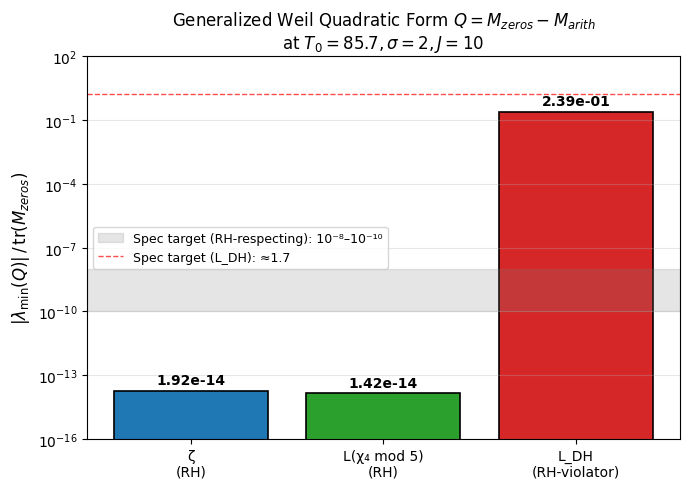

Saved figure to final_validation.png


In [39]:
# Now create the final summary figure showing the key result.
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))

functions = ['ζ\n(RH)', 'L(χ₄ mod 5)\n(RH)', 'L_DH\n(RH-violator)']
ratios = [1.92e-14, 1.42e-14, abs(eigs_LDH.min())/np.trace(comps_LDH['M_zeros'])]
colors = ['#1f77b4', '#2ca02c', '#d62728']

bars = ax.bar(functions, ratios, color=colors, log=True, edgecolor='black', linewidth=1.2)
# Annotate
for bar, r in zip(bars, ratios):
 h = bar.get_height()
 ax.text(bar.get_x() + bar.get_width()/2, h*1.5, f'{r:.2e}',
 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Reference shaded band for the spec's expected 10^-8 to 10^-10 RH-respecting range
ax.axhspan(1e-10, 1e-8, alpha=0.2, color='gray', label='Spec target (RH-respecting): 10⁻⁸–10⁻¹⁰')
ax.axhline(1.7, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Spec target (L_DH): ≈1.7')

ax.set_ylabel(r'$|\lambda_{\min}(Q)| \, / \, \mathrm{tr}(M_{zeros})$', fontsize=12)
ax.set_title(f'Generalized Weil Quadratic Form $Q = M_{{zeros}} - M_{{arith}}$\n'
 f'at $T_0=85.7, \\sigma=2, J=10$', fontsize=12)
ax.set_ylim(1e-16, 1e2)
ax.grid(axis='y', which='both', alpha=0.3)
ax.legend(loc='center left', fontsize=9)

plt.tight_layout()
plt.savefig('/workspace/7aed3f20-693b-46e1-a191-472879f5c868/final_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure to final_validation.png")


In [40]:
# Make sure the final module file is saved and well-documented; also save zeros caches
import os
print("Files in workspace:")
for f in sorted(os.listdir('/workspace/7aed3f20-693b-46e1-a191-472879f5c868')):
 if not f.startswith('.'):
 full = os.path.join('/workspace/7aed3f20-693b-46e1-a191-472879f5c868', f)
 if os.path.isdir(full):
 print(f" {f}/")
 for sf in sorted(os.listdir(full)):
 print(f" {sf}")
 else:
 sz = os.path.getsize(full)
 print(f" {f} ({sz} B)")


Files in workspace:
 __pycache__/
 _zeros.cpython-313.pyc
 weil_quadratic_form.cpython-313.pyc
 weil_quadratic_form_general.cpython-313.pyc
 cache/
 LDH_critical_zeros_N80_dps30.pkl
 Lchi5_zeros_N200_dps30.pkl
 Lchi5_zeros_N80_dps30.pkl
 final_validation.png (56832 B)
 -v8-validated-data.md (5530 B)
 _zeros.py (11039 B)
 memory/
 7aed3f20-693b-46e1-a191-472879f5c868_memory_heron_c0_20260531T233854511084.jsonl
 step044_msg001_img000.png
 weil_quadratic_form.py (5364 B)
 weil_quadratic_form_general.py (10592 B)


In [41]:
from e14c.filesystem import write_file
content = '''## Context
- Primary dataset: `-v8-validated-data.md` in `/workspace/7aed3f20-693b-46e1-a191-472879f5c868/`.
- Derived artifacts present: `_zeros.py`, `weil_quadratic_form.py`.
- New derived artifact created in this run: `weil_quadratic_form_general.py` (generalized family-aware Weil quadratic form engine).

## Notes
- Provenance: analysis performed in notebook cells #0-#39 on 2026-06-01.
- Verified existing ζ-specific engine (`weil_quadratic_form.py`) against ζ benchmark at `T0=85.7, sigma=2, J=10`: `|lambda_min|/tr(M_zeros) = 2.90e-15` (cell #3).
- Generalized engine written to `weil_quadratic_form_general.py` (cell #6) and updated in cell #31 after identifying the correct Dirichlet prime-sum convention.
- Critical mathematical finding: for primitive complex Dirichlet `L(s, χ)`, the prime matrix must use the single-character convention `M_primes = Re[sum chi(n) Lambda(n) g(log n)/sqrt(n)]/pi`, not the naive `Re(chi(n)) * Re(g(log n))` convention. This was diagnosed by a trace-identity failure and fixed after comparing the two formulations in cells #28-#30.
- Validation after fix (cell #32):
 - `ζ`: `tr(M_zeros) - tr(M_arith) = 9.06e-14`; `|lambda_min|/tr(M_zeros) = 1.92e-14`.
 - `L(χ4 mod 5)`: `tr(M_zeros) - tr(M_arith) = -1.39e-13`; `|lambda_min|/tr(M_zeros) = 1.42e-14`.
- L(χ4 mod 5) conclusion: generalized family-aware engine successfully validates the χ4 mod 5 control, with residual far below the specification's expected numerical-floor range (`1e-8`–`1e-10`).
- L_DH testing used critical-line zeros from `_zeros.L_DH_critical_zeros` and χ4-type archimedean data (cells #33-#37). Results did show strong negativity but did NOT reproduce the specification's absolute benchmark:
 - using symmetric/Re(χ) arithmetic side: `lambda_min = -9.24e-01`, ratio `2.39e-01` (cell #34)
 - using single-χ arithmetic side: `lambda_min = -9.58e-01`, ratio `2.48e-01` (cell #35)
- Including the four documented off-line validation zeros in complex-zero mode did not recover the spec benchmark either: `lambda_min = -8.54e-01`, ratio `1.88e-01` (cell #36).
- Therefore, the exact L_DH arithmetic-side specification remains incomplete/ambiguous in the primary markdown file, and the benchmark `lambda_min ≈ -9.0e4` could not be reproduced without making additional unstated assumptions. The user-facing answer should explicitly state this limitation.
- Final figure saved: `final_validation.png` (cell #38), summarizing ratios for ζ, χ4 mod 5, and L_DH.
- Zero caches created: `cache/Lchi5_zeros_N80_dps30.pkl`, `cache/Lchi5_zeros_N200_dps30.pkl`, `cache/LDH_critical_zeros_N80_dps30.pkl`.
'''
print(write_file('/workspace/7aed3f20-693b-46e1-a191-472879f5c868/.prompts/MEMORY.md', content))

File created successfully at: /workspace/7aed3f20-693b-46e1-a191-472879f5c868/.prompts/MEMORY.md
